In [1]:
import os 
os.getcwd()
os.chdir('/home/shivamsingh/Projects/SPINE/gait_ml/')

%matplotlib inline
%load_ext autoreload
%autoreload 2

import json
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from scipy.signal import find_peaks, peak_widths, butter, sosfiltfilt
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "notebook"

from ahrs.filters import Madgwick
from scipy.signal import savgol_filter
from scipy.spatial.transform import Rotation

import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

#2mW and TUG
from src.gait_ml.data.dataset import GaitDataset
from src.gait_ml.gait import utils
from src.gait_ml.features.gait_imu_parameters import compute_gait_imu_parameters, get_gait_features
from src.gait_ml.features.tug_imu_parameters import compute_tug_imu_parameters
#STS and TM
from src.gait_ml.features.sts_imu_parameters import (
    get_sts_imu_features_single, get_sts_imu_features
)
from src.gait_ml.features.trunk_motion_imu import (
    compute_rom_from_file, compute_all_trunk_motion_for_subject
)
#Infernece module
from src.gait_ml.inference.motoric_feature_pipeline  import (
    infer_all_subjects, infer_subject_features
)

from configs.config import (
    DATA_PROCESSED, 
    OUTPUT_DIR,
    DATAFRAMES,
    DATASETS_02,
    DATASETS_02_T1,
    DATASETS_02_T2,
    SMART_PHONE_DATA_DIR
    )
import warnings

warnings.filterwarnings("ignore")

# Inference for a single subject 

# 1. GAIT:2mW

In [2]:
# Example: all gait files in a folder (2mW test)
xls_files = sorted(glob("/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls",))

window_size = 256
step_size = 128
sampling_rate_hz = 100
trajectory_estimation_method = "RtsKalman"
analyze_first_10_strides = False
verbose = True

df_gait, df_fail = compute_gait_imu_parameters(
    xls_files=xls_files,
    window_size=window_size,
    step_size=step_size,
    sampling_rate_hz=sampling_rate_hz,
    trajectory_estimation_method=trajectory_estimation_method,
    analyze_first_10_strides=analyze_first_10_strides,
    verbose=verbose,
)

print(df_gait)
print(df_fail)


# gait_files = glob(os.path.join(subject_folder, "*_2mW_IPhone.xls"))
# df_gait, fail_gait = compute_gait_imu_parameters(gait_files)


--- Processing subject 01 (01_2_2mW_IPhone.xls) ---

🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)

✅ All files processed successfully!

✔ Gait IMU extraction complete.
• Successful: 1 subjects
• Failed: 0
   id                 file  mean_stride_length [m]  mean_gait_velocity [m/s]  \
0  01  01_2_2mW_IPhone.xls                0.943391                  0.903809   

   stride_length_spatial [m]  gait_velocity_spatial [m/s]  max_sensor_lift [m]  
0                   0.943391                     0.903809             0.020348  
Empty DataFrame
Columns: []
Index: []


In [3]:
df_gait

,id,file,mean_stride_length [m],mean_gait_velocity [m/s],stride_length_spatial [m],gait_velocity_spatial [m/s],max_sensor_lift [m]
0,01,01_2_2mW_IPhone.xls,0.943391,0.903809,0.943391,0.903809,0.020348


In [4]:
df_spatial_t1 = get_gait_features(xls_files, 
                                                    window_size, 
                                                    step_size, 
                                                    sampling_rate_hz, 
                                                    trajectory_estimation_method=trajectory_estimation_method,
                                                    analyze_first_10_strides=analyze_first_10_strides
                                                    )

print("Spatial mean stride length [m]: ", df_spatial_t1['stride length [m]'].mean())
print("Spatial mean gait velocity [m/s]: ", df_spatial_t1['gait velocity [m/s]'].mean())
df_spatial_t1


🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)

✅ All files processed successfully!
Spatial mean stride length [m]:  0.9433913043478261
Spatial mean gait velocity [m/s]:  0.903808695652174


,gait velocity [m/s],stride length [m],max. sensor lift [m],file
0,1.027,1.119,0.038,01_2_2mW_IPhone
1,1.125,1.125,0.004,01_2_2mW_IPhone
2,0.918,0.918,0.064,01_2_2mW_IPhone
3,0.444,0.440,0.006,01_2_2mW_IPhone
4,0.202,0.198,0.033,01_2_2mW_IPhone
...,...,...,...,...
110,0.253,0.266,0.010,01_2_2mW_IPhone
111,0.883,0.928,0.075,01_2_2mW_IPhone
112,1.245,1.294,0.002,01_2_2mW_IPhone
113,1.299,1.325,0.002,01_2_2mW_IPhone


In [5]:
# RUN for 10 initial strides

df_gait, df_fail = compute_gait_imu_parameters(
    xls_files=xls_files,
    window_size=window_size,
    step_size=step_size,
    sampling_rate_hz=sampling_rate_hz,
    trajectory_estimation_method=trajectory_estimation_method,
    analyze_first_10_strides=True,#***
    verbose=verbose,
)
df_gait


--- Processing subject 01 (01_2_2mW_IPhone.xls) ---

🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)

✅ All files processed successfully!

✔ Gait IMU extraction complete.
• Successful: 1 subjects
• Failed: 0


,id,file,mean_stride_length [m],mean_gait_velocity [m/s],stride_length_spatial [m],gait_velocity_spatial [m/s],max_sensor_lift [m]
0,01,01_2_2mW_IPhone.xls,0.847875,0.830625,0.847875,0.830625,0.034875


# 2. Trunk Motion: Left + Right 

## 2a. LEFT

ROM: 38.699281707543854°


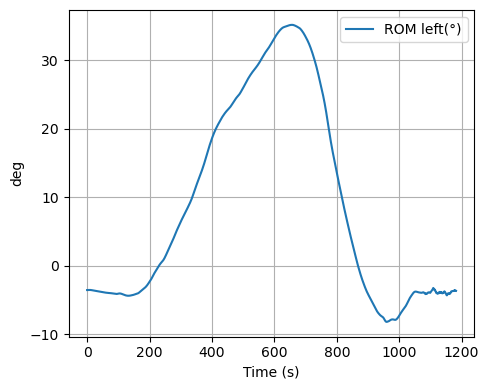

,id,file_name,flexion_type,axis,rom_deg
0,01,01_2_lat_l,left,pitch,38.699282


In [6]:

filepath = "/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_lat_l.xls"
flexion_type = "left"  # left/right/ant/post
sampling_rate = 100.0
axis = "pitch"
plot = True
beta = 0.1

df_row = compute_rom_from_file(
    filepath=filepath,
    flexion_type=flexion_type,  # left/right/ant/post
    sampling_rate=sampling_rate,
    axis=axis,
    beta=beta,
    plot=plot,
)
df_row


## 2b. RIGHT

ROM: 33.06209991390477°


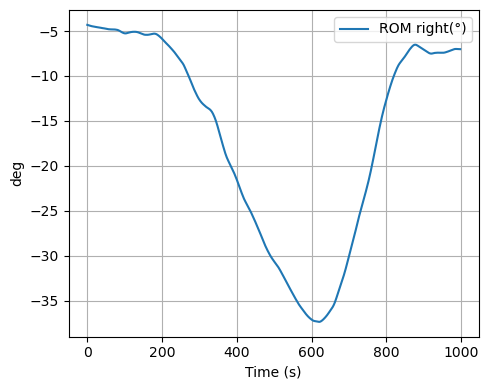

,id,file_name,flexion_type,axis,rom_deg
0,01,01_2_lat_r,right,pitch,33.0621


In [7]:


filepath = "/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_lat_r.xls"
flexion_type = "right"  # left/right/ant/post
sampling_rate = 100.0
axis = "pitch"
plot = True
beta = 0.1

df_row = compute_rom_from_file(
    filepath=filepath,
    flexion_type=flexion_type,  # left/right/ant/post
    sampling_rate=sampling_rate,
    axis=axis,
    beta=beta,
    plot=plot,
)
df_row

## 2c. All four ROMs: Anterior, Posterior, Lateral-left, Lateral-right

In [8]:
example_subject = os.path.join(DATASETS_02_T2, "ID_01_T2")

df_trunk = compute_all_trunk_motion_for_subject(
    subject_folder=example_subject,
    sampling_rate=100.0,
    beta=0.1,
    plot=False,
)
df_trunk

,id,rom_ant_deg,rom_left_deg,rom_post_deg,rom_right_deg
0,01,10.054648,38.699282,25.239901,33.0621


# 3. TUG: single task

['/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls']
Found 1 TUG files.
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls
Skipping: 295:330 | index 0 is out of bounds for axis 0 with size 0
Skipping: 962:979 | index 0 is out of bounds for axis 0 with size 0
Skipping: 979:996 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)

Processing subject: 01


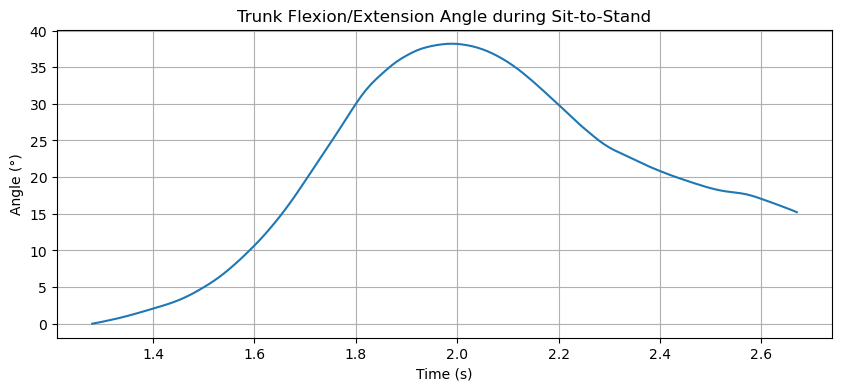

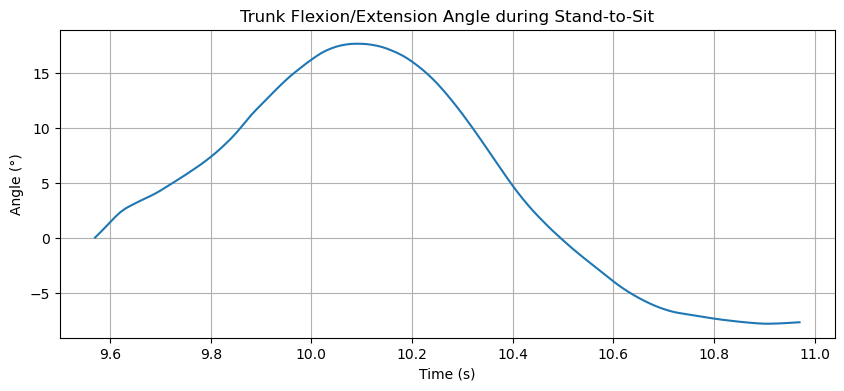


✔️ TUG feature extraction complete.
Subjects processed: 1
Subjects failed: 0


,id,sit_to_stand [s],walk_forward [s],turn_1 [s],walk_back [s],turn_2 [s],stand_to_sit [s],total_duration [s],Sit to stand_Antero-Posterior Acceleration range [m/s^2],Sit to stand_Lateral acceleration range [m/s^2],...,Sit to stand_Extension range [°],Stand to sit_Antero-Posterior Acceleration range [m/s^2],Stand to sit_Lateral acceleration range [m/s^2],Stand to sit_Vertical acceleration range [m/s^2],Stand to sit_Flexion range [°],Stand to sit_Extension range [°],Mid turning_Peak angular speed [°/s],Mid turning_Average angular speed [°/s],End turning_Peak angular speed [°/s],End turning_Average angular speed [°/s]
0,01,1.4,2.01,2.08,1.33,1.47,1.41,9.7,9.126671,1.795516,...,22.978889,5.856422,3.166964,4.838838,17.633912,25.462937,157.991278,76.973521,195.971979,99.625883


In [9]:

xls_file = [ f"/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls"]
print(xls_file)

df_tug_features, df_failed  = compute_tug_imu_parameters(
    xls_files=xls_file,
    acc_sheet_name="Accelerometer",
    window_size=256,
    step_size=128,
    sampling_rate_hz=100,
    verbose=True,
)

df_tug_features

# 4. STS5r

## 4a. Single subject

In [10]:
file_path = os.path.join(
    DATASETS_02_T2,
    "ID_01_T2",
    "01_2_STS5r.xls"
)

df_sts_single = get_sts_imu_features_single(file_path)
df_sts_single.T


,0
STS_total_time,12.09
sit2stand_average_time,1.19
stand2sit_average_time,1.23
sit2stand_time_SD,0.09
stand2sit_time_SD,0.23
sit2stand_variability_time,7.72
stand2sit_variability_time,18.75
time_asymmetry,-2.85
Rep_duration_avg,2.42
Rep_Time_SD,0.24


## 4b. RUN STS5r - ALL SUBJECTS

In [12]:
sts_files = sorted(glob(os.path.join(DATASETS_02_T2, "ID_*_T2", "*STS5r.xls")))

df_sts = get_sts_imu_features(sts_files)
df_sts

,STS_total_time,sit2stand_average_time,stand2sit_average_time,sit2stand_time_SD,stand2sit_time_SD,sit2stand_variability_time,stand2sit_variability_time,time_asymmetry,Rep_duration_avg,Rep_Time_SD,...,STS_Angular_Velocity_Asymmetry,Mean_acceleration,Peak_acceleration,Mean_angular_velocity,Peak_angular_velocity,Mean_jerk_rms,Peak_jerk_rms,Rep_variability_jerk,subject_id,file_path
0,12.09,1.19,1.23,0.09,0.23,7.72,18.75,-2.85,2.42,0.24,...,1.10,1.83,5.56,45.43,100.79,15.19,26.28,39.18,1,/home/shivamsingh/Projects/SPINE/data/dataset_...
1,11.95,1.36,1.08,0.18,0.42,13.43,39.03,20.10,2.39,0.31,...,8.38,1.55,4.85,42.10,97.56,10.54,16.67,45.18,2,/home/shivamsingh/Projects/SPINE/data/dataset_...
2,6.57,0.80,0.84,0.15,0.10,18.36,11.99,-4.95,1.64,0.14,...,58.68,2.00,9.05,26.96,96.26,23.32,44.45,66.50,3,/home/shivamsingh/Projects/SPINE/data/dataset_...
3,7.36,0.82,1.02,0.09,0.05,10.64,5.20,-24.09,1.84,0.07,...,15.36,2.51,8.93,48.19,145.24,29.69,54.47,51.41,4,/home/shivamsingh/Projects/SPINE/data/dataset_...
4,7.97,0.76,0.83,0.11,0.40,14.48,47.66,-8.64,1.59,0.36,...,3.18,3.08,10.68,50.45,134.08,40.03,76.03,49.49,5,/home/shivamsingh/Projects/SPINE/data/dataset_...
5,10.91,0.90,1.28,0.21,1.36,23.30,106.42,-41.37,2.18,1.17,...,31.58,2.39,9.34,33.86,89.64,31.36,42.84,33.33,7,/home/shivamsingh/Projects/SPINE/data/dataset_...
6,8.83,0.82,0.94,0.38,0.04,46.30,4.71,-14.84,1.77,0.36,...,17.36,2.08,7.70,38.63,96.34,20.71,32.27,48.76,8,/home/shivamsingh/Projects/SPINE/data/dataset_...
7,6.20,0.74,0.80,0.06,0.06,7.46,7.95,-8.20,1.55,0.05,...,18.88,2.06,7.92,31.71,80.07,21.99,33.76,51.44,9,/home/shivamsingh/Projects/SPINE/data/dataset_...
8,9.42,0.89,0.99,0.11,0.27,11.93,27.25,-11.21,1.88,0.24,...,15.79,2.96,10.38,57.68,145.99,33.32,64.35,60.30,10,/home/shivamsingh/Projects/SPINE/data/dataset_...
9,8.67,0.85,0.92,0.38,0.14,44.56,15.63,-8.90,1.73,0.41,...,7.06,1.75,5.51,41.54,102.68,21.28,32.66,41.65,11,/home/shivamsingh/Projects/SPINE/data/dataset_...


# 5. Inference Pipeline

## 5a. Usage: Run inference for ONE subject


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2 ===

🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 01_2_2mW_IPhone.xls: Stride Length = 6.71 m, Gait Velocity = 6.41 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls
Skipping: 295:330 | index 0 is out of bounds for axis 0 with size 0
Skipping: 962:979 | index 0 is out of bounds for axis 0 with size 0
Skipping: 979:996 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


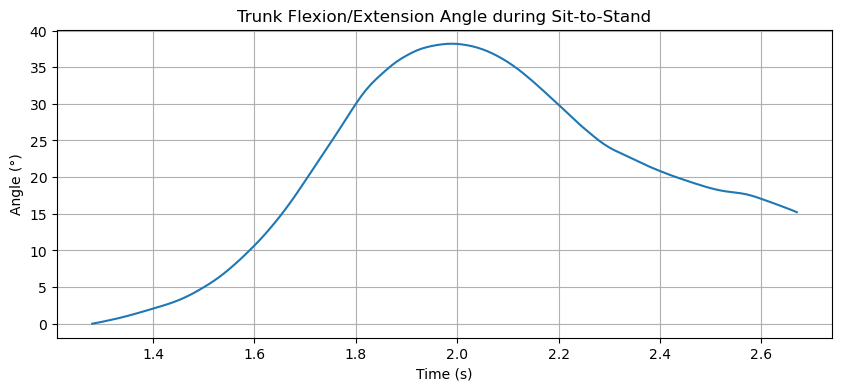

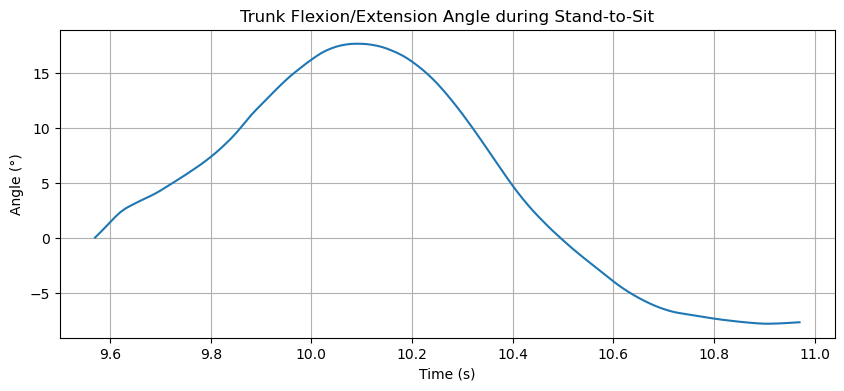


=== FINAL FEATURE TABLE (one subject) ===


,0
id,01
mean_stride_length [m],6.711209
mean_gait_velocity [m/s],6.408826
max_sensor_lift [m],0.020348
stride_length_spatial [m],0.943391
gait_velocity_spatial [m/s],0.903809
sit_to_stand [s],1.4
walk_forward [s],2.01
turn_1 [s],2.08
walk_back [s],1.33



=== TEST-BY-TEST DETAILS ===

--- GAIT ---


,id,mean_stride_length [m],mean_gait_velocity [m/s],max_sensor_lift [m],stride_length_spatial [m],gait_velocity_spatial [m/s]
0,01,6.711209,6.408826,0.020348,0.943391,0.903809



--- TUG ---


...

,STS_total_time,sit2stand_average_time,stand2sit_average_time,sit2stand_time_SD,stand2sit_time_SD,sit2stand_variability_time,stand2sit_variability_time,time_asymmetry,Rep_duration_avg,Rep_Time_SD,...,Mean_acceleration,Peak_acceleration,Mean_angular_velocity,Peak_angular_velocity,Mean_jerk_rms,Peak_jerk_rms,Rep_variability_jerk,file_path,label,id
0,12.09,1.19,1.23,0.09,0.23,7.72,18.75,-2.85,2.42,0.24,...,1.83,5.56,45.43,100.79,15.19,26.28,39.18,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,01



--- TRUNK ---


,id,rom_ant_deg,rom_left_deg,rom_post_deg,rom_right_deg
0,01,10.054648,38.699282,25.239901,33.0621



=== ERRORS (if any) ===


""


In [14]:
# Pick one subject folder
subject_folder = os.path.join(DATASETS_02_T2, "ID_01_T2")

# Run inference
full_df, details, errors = infer_subject_features(
    subject_folder,
    verbose=True
) 

print("\n=== FINAL FEATURE TABLE (one subject) ===")
display(full_df.T)     # transpose for readability

print("\n=== TEST-BY-TEST DETAILS ===")
for test_name, df in details.items():
    print(f"\n--- {test_name.upper()} ---")
    display(df)

print("\n=== ERRORS (if any) ===")
display(errors)


In [15]:
full_df.T

,0
id,01
mean_stride_length [m],6.711209
mean_gait_velocity [m/s],6.408826
max_sensor_lift [m],0.020348
stride_length_spatial [m],0.943391
gait_velocity_spatial [m/s],0.903809
sit_to_stand [s],1.4
walk_forward [s],2.01
turn_1 [s],2.08
walk_back [s],1.33


## 5b. Usage: Run inference for ALL subjects


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2 ===

🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 01_2_2mW_IPhone.xls: Stride Length = 6.71 m, Gait Velocity = 6.41 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls
Skipping: 295:330 | index 0 is out of bounds for axis 0 with size 0
Skipping: 962:979 | index 0 is out of bounds for axis 0 with size 0
Skipping: 979:996 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


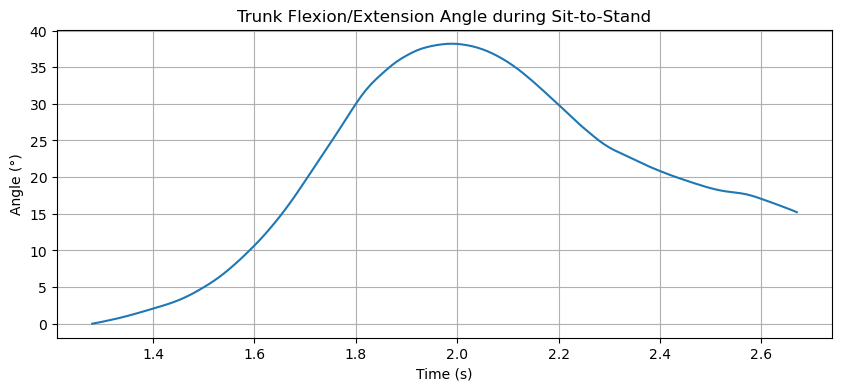

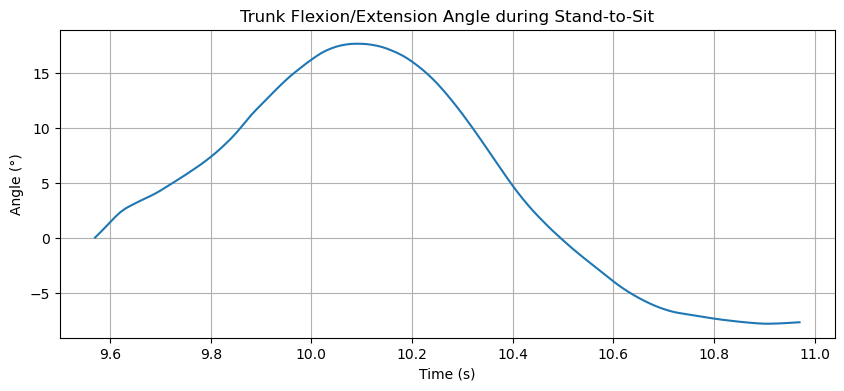


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2 ===

🔹 Processing file: 02_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2/02_2_2mW_IPhone.xls
cropped_array shape: (97, 256, 7)
all_arrays shape: (97, 256, 7)
✅ 02_2_2mW_IPhone.xls: Stride Length = 6.74 m, Gait Velocity = 6.74 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2/02_2_TUGst.xls
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


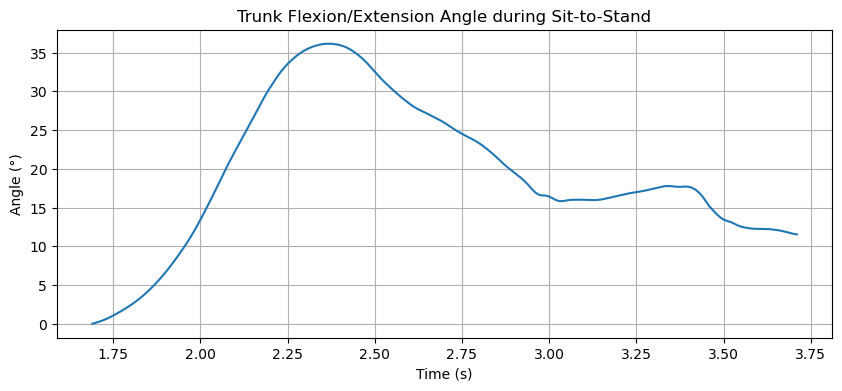

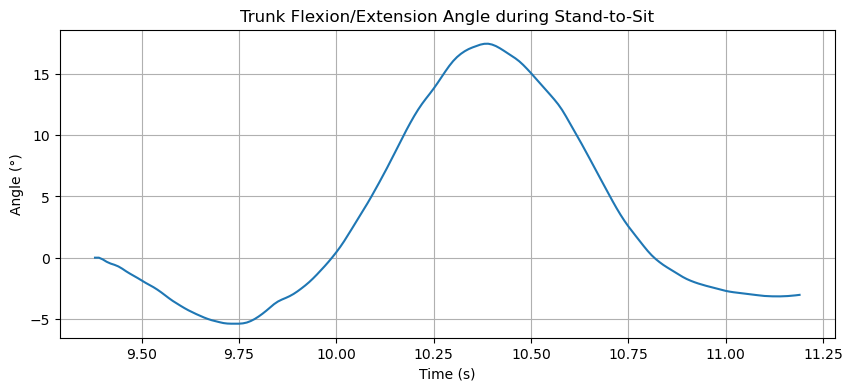


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2 ===

🔹 Processing file: 03_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2/03_2_2mW_IPhone.xls
Skipping: 9045:9053 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (104, 256, 7)
all_arrays shape: (104, 256, 7)
✅ 03_2_2mW_IPhone.xls: Stride Length = 7.30 m, Gait Velocity = 8.54 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2/03_2_TUGst.xls
Skipping: 831:885 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
❌ Error processing 03: Turn-1 occurs before sit-to-stand – check signal / labels.

=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_04_T2 ===

🔹 Processing file: 04_2_2mW_IPhone.xls
/hom

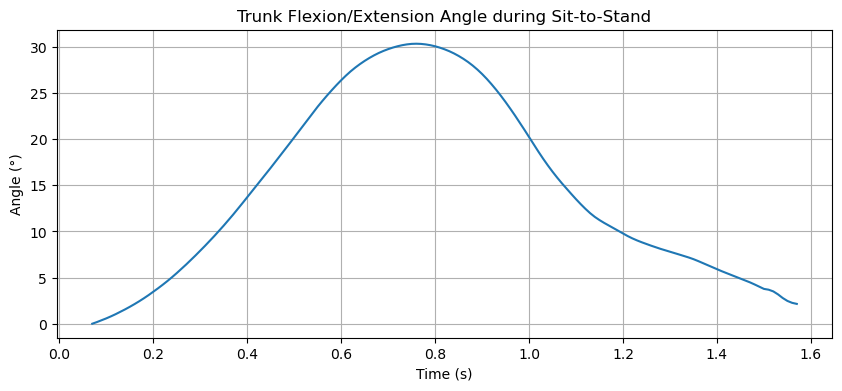

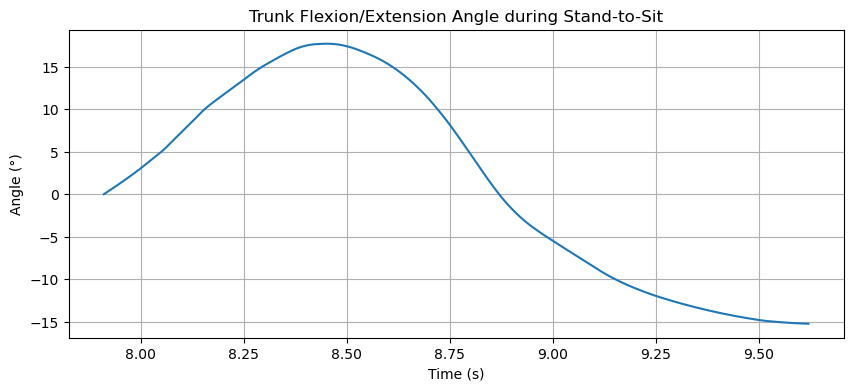


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_07_T2 ===

🔹 Processing file: 07_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_07_T2/07_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 07_2_2mW_IPhone.xls: Stride Length = 6.63 m, Gait Velocity = 7.19 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_07_T2/07_2_TUGst.xls
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


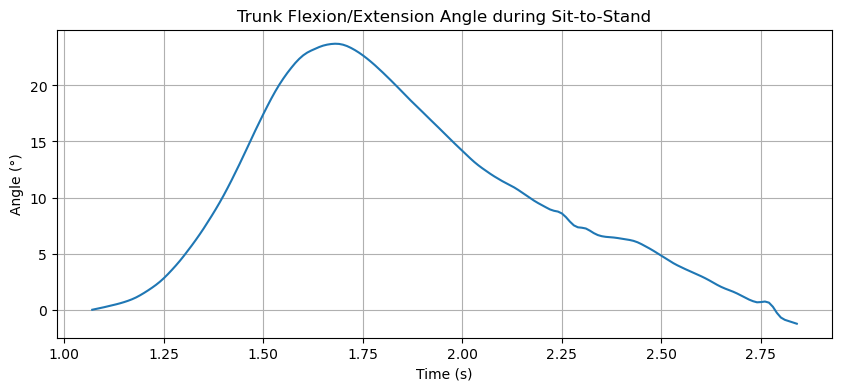

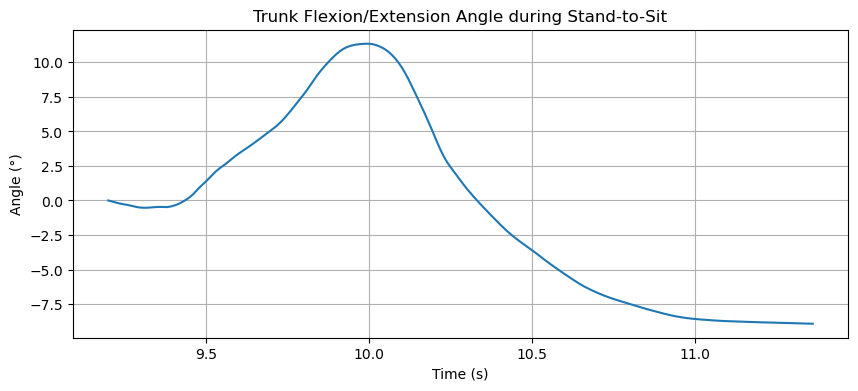


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_08_T2 ===

🔹 Processing file: 08_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_08_T2/08_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 08_2_2mW_IPhone.xls: Stride Length = 6.75 m, Gait Velocity = 7.35 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_08_T2/08_2_TUGst.xls
Skipping: 983:1008 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1008:1029 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1029:1050 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


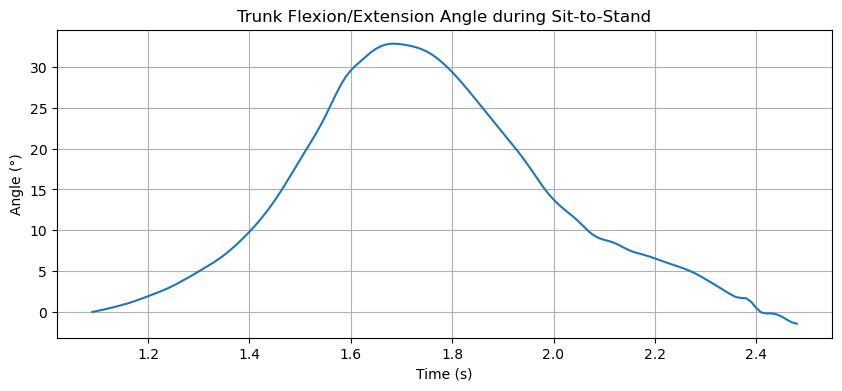

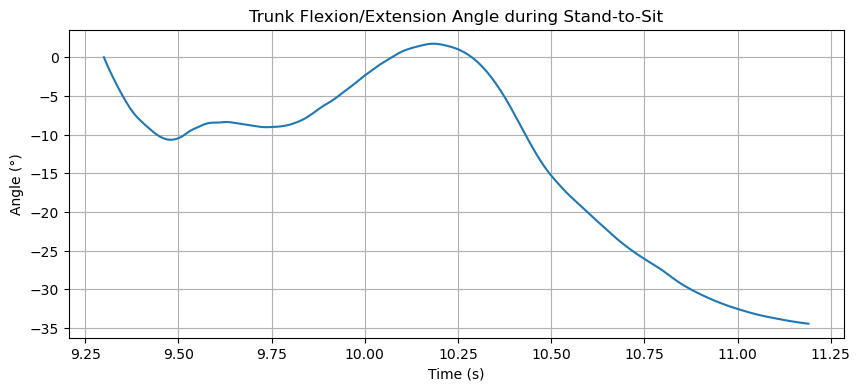


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_09_T2 ===

🔹 Processing file: 09_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_09_T2/09_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 09_2_2mW_IPhone.xls: Stride Length = 6.63 m, Gait Velocity = 8.14 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_09_T2/09_2_TUGst.xls
Skipping: 481:508 | index 0 is out of bounds for axis 0 with size 0
Skipping: 899:937 | index 0 is out of bounds for axis 0 with size 0
Skipping: 937:958 | index 0 is out of bounds for axis 0 with size 0
Skipping: 958:986 | index 0 is out of bounds for axis 0 with size 0
Skipping: 986:1014 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


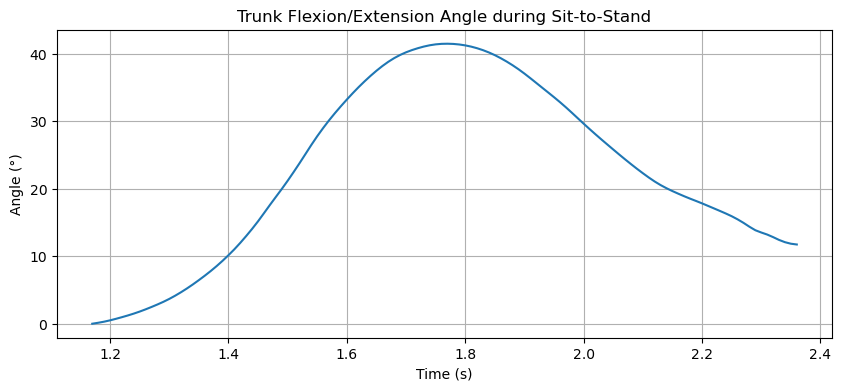

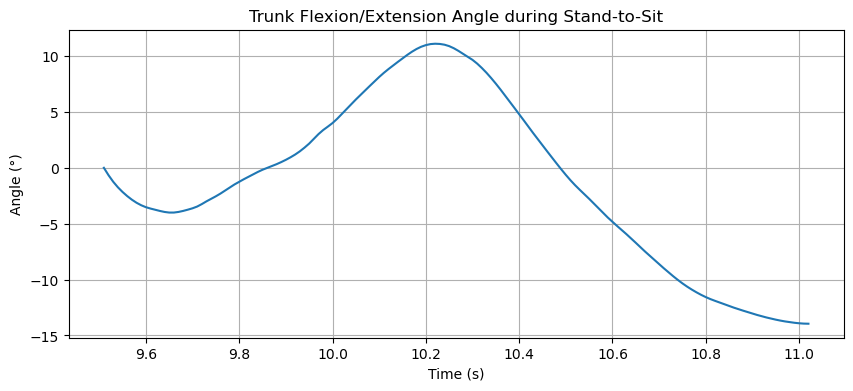


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_10_T2 ===

🔹 Processing file: 10_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_10_T2/10_2_2mW_IPhone.xls
Skipping: 12928:13039 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 10_2_2mW_IPhone.xls: Stride Length = 7.08 m, Gait Velocity = 6.29 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_10_T2/10_2_TUGst.xls
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


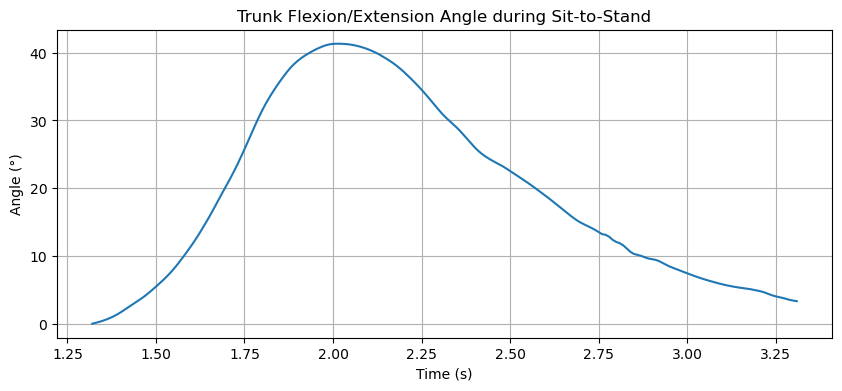

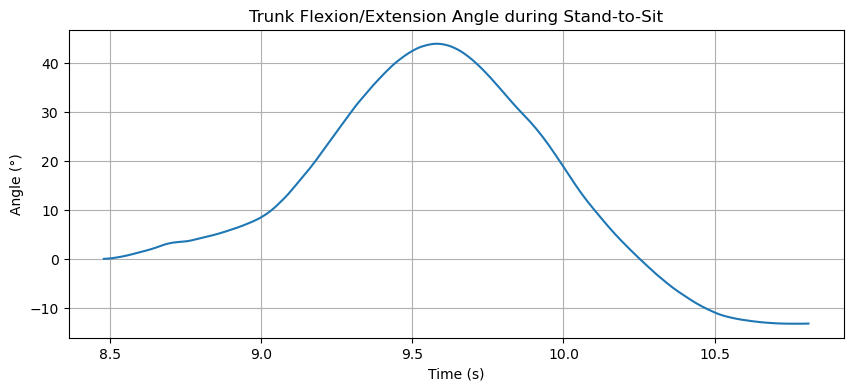


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_11_T2 ===

🔹 Processing file: 11_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_11_T2/11_2_2mW_IPhone.xls
Skipping: 13039:13125 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 11_2_2mW_IPhone.xls: Stride Length = 6.89 m, Gait Velocity = 7.74 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_11_T2/11_2_TUGst.xls
Skipping: 520:549 | index 0 is out of bounds for axis 0 with size 0
Skipping: 948:975 | index 0 is out of bounds for axis 0 with size 0
Skipping: 975:1011 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1011:1047 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


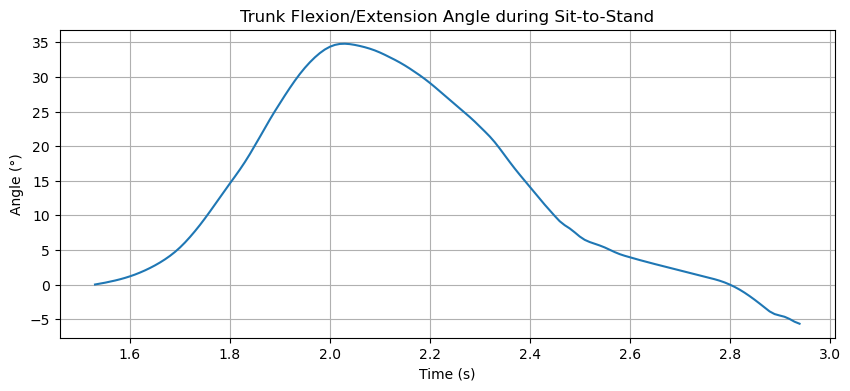

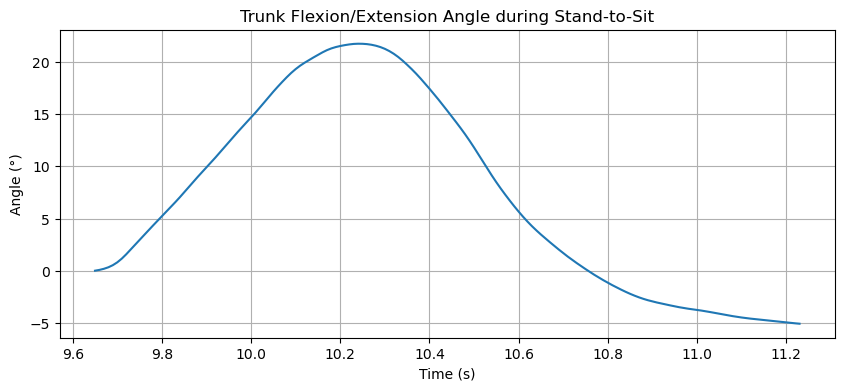


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_12_T2 ===

🔹 Processing file: 12_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_12_T2/12_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 12_2_2mW_IPhone.xls: Stride Length = 7.08 m, Gait Velocity = 7.44 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_12_T2/12_2_TUGst.xls
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


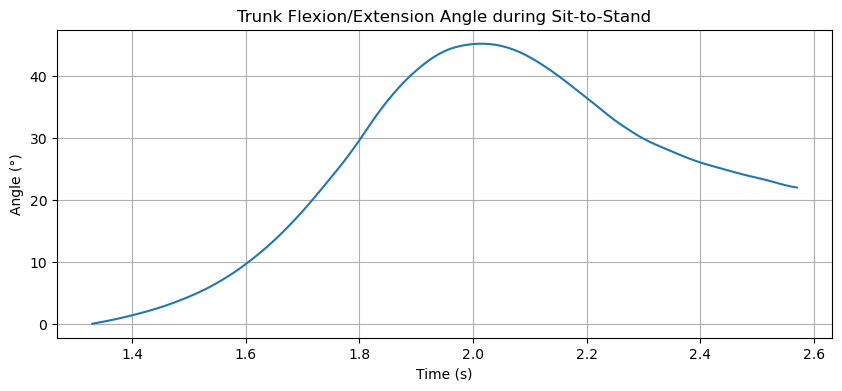

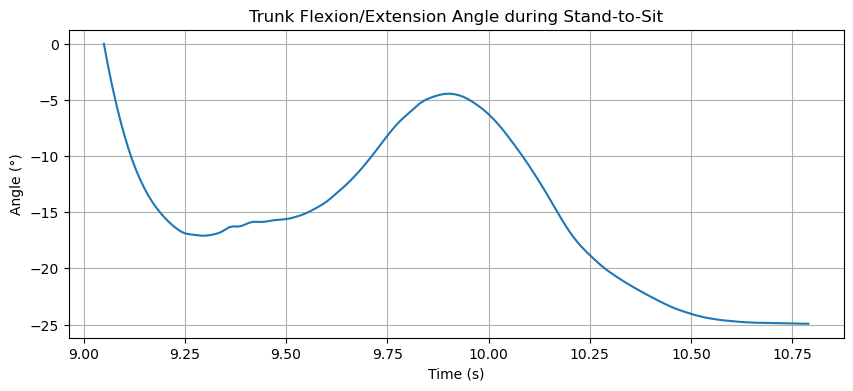


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_13_T2 ===

🔹 Processing file: 13_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_13_T2/13_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 13_2_2mW_IPhone.xls: Stride Length = 6.72 m, Gait Velocity = 7.71 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_13_T2/13_2_TUGst.xls
cropped_array shape: (6, 256, 7)
all_arrays shape: (6, 256, 7)


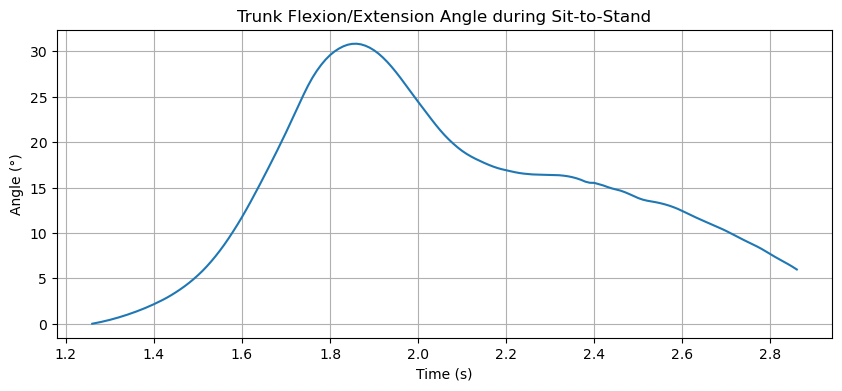

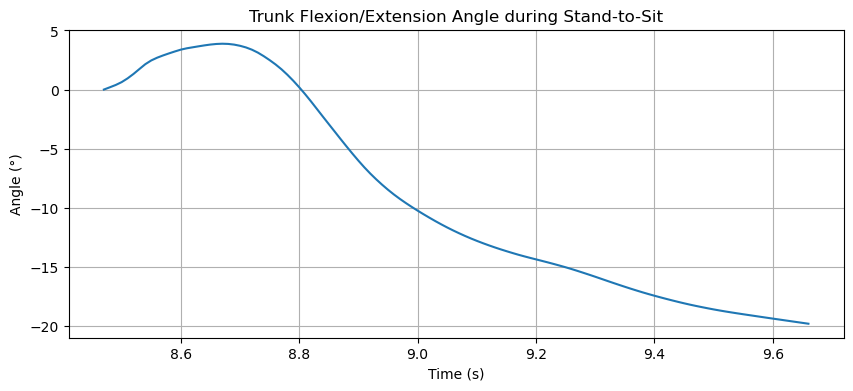


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_14_T2 ===

🔹 Processing file: 14_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_14_T2/14_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 14_2_2mW_IPhone.xls: Stride Length = 6.67 m, Gait Velocity = 7.85 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_14_T2/14_2_TUGst.xls
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)


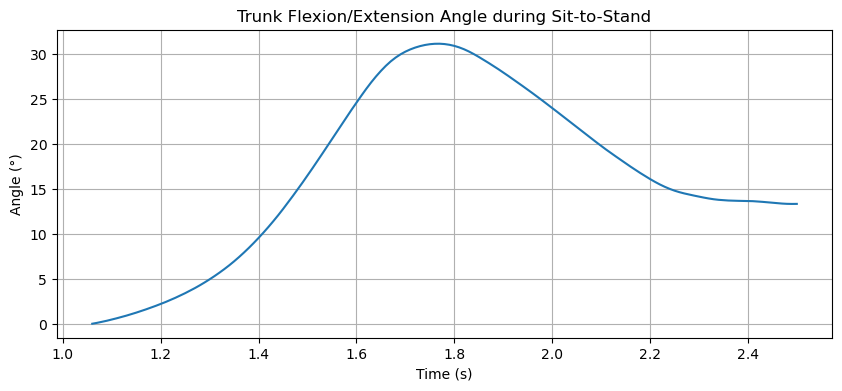

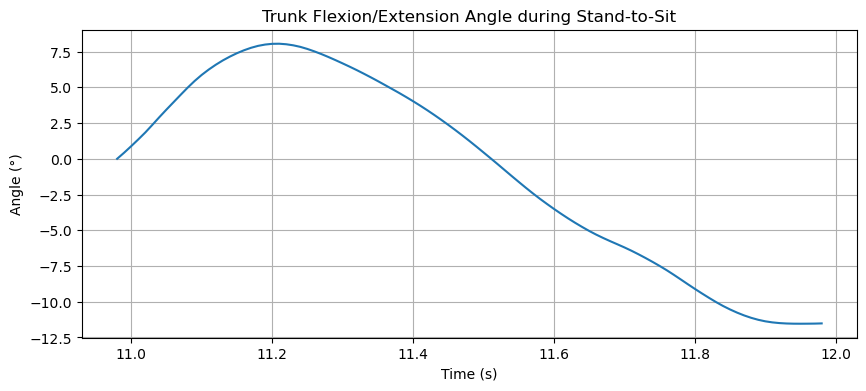


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_15_T2 ===

🔹 Processing file: 15_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_15_T2/15_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 15_2_2mW_IPhone.xls: Stride Length = 6.85 m, Gait Velocity = 9.48 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_15_T2/15_2_TUGst.xls
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)


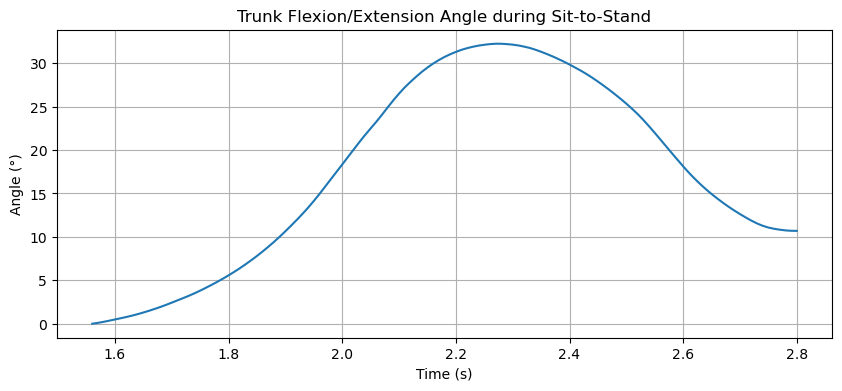

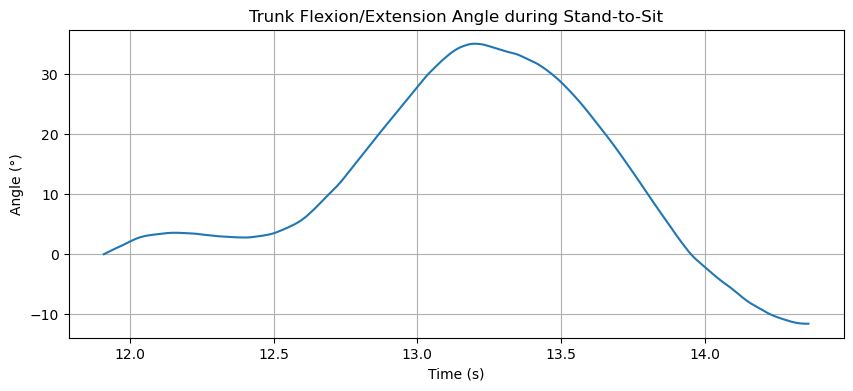


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_16_T2 ===

🔹 Processing file: 16_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_16_T2/16_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 16_2_2mW_IPhone.xls: Stride Length = 6.99 m, Gait Velocity = 7.79 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_16_T2/16_2_TUGst.xls
Skipping: 339:366 | index 0 is out of bounds for axis 0 with size 0
Skipping: 432:463 | index 0 is out of bounds for axis 0 with size 0
Skipping: 528:552 | index 0 is out of bounds for axis 0 with size 0
Skipping: 941:996 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


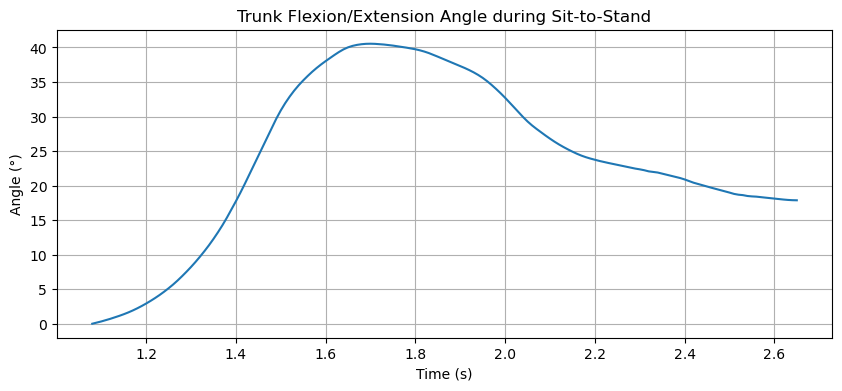

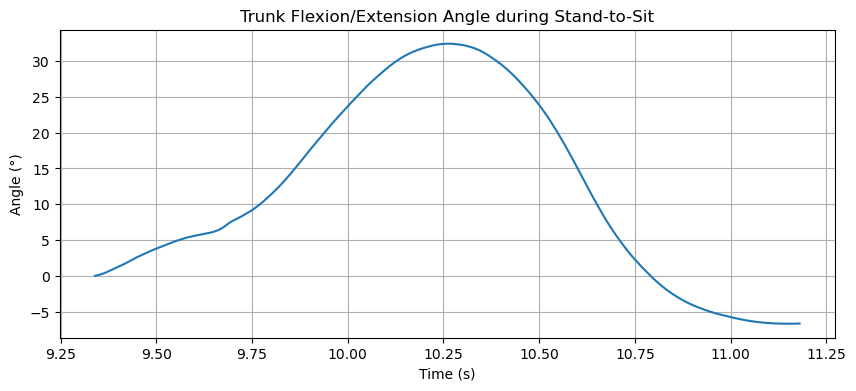


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_17_T2 ===

🔹 Processing file: 17_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_17_T2/17_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 17_2_2mW_IPhone.xls: Stride Length = 6.70 m, Gait Velocity = 6.71 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_17_T2/17_2_TUGst.xls
Skipping: 1074:1113 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)


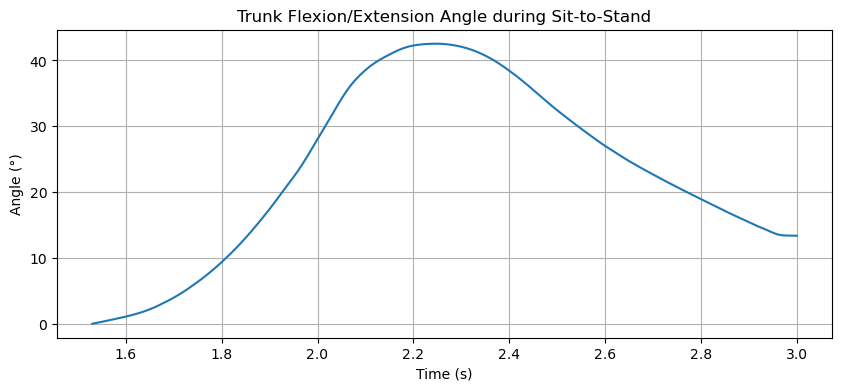

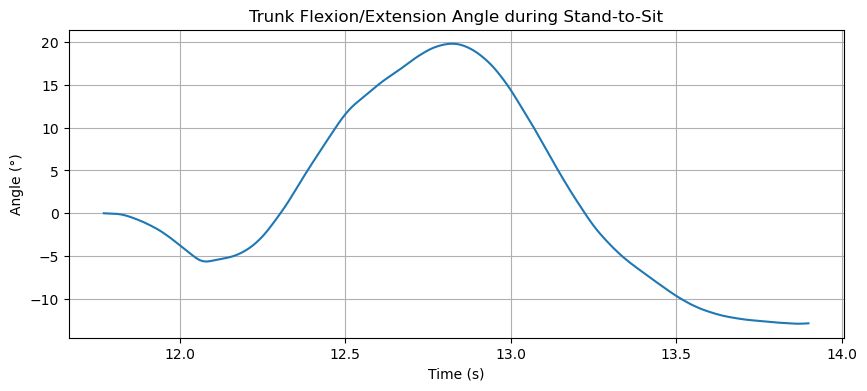


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_18_T2 ===

🔹 Processing file: 18_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_18_T2/18_2_2mW_IPhone.xls
cropped_array shape: (103, 256, 7)
all_arrays shape: (103, 256, 7)
✅ 18_2_2mW_IPhone.xls: Stride Length = 6.96 m, Gait Velocity = 8.07 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_18_T2/18_2_TUGst.xls
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


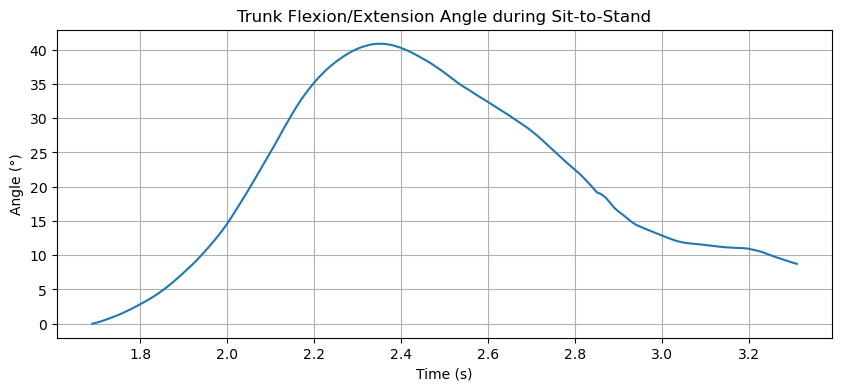

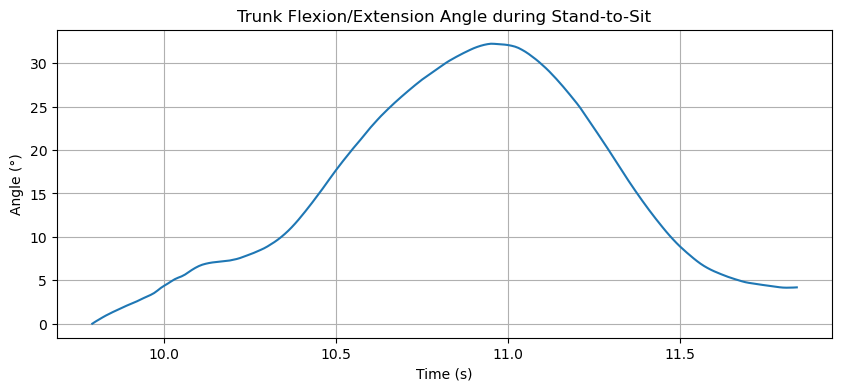


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_19_T2 ===

🔹 Processing file: 19_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_19_T2/19_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 19_2_2mW_IPhone.xls: Stride Length = 6.82 m, Gait Velocity = 7.14 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_19_T2/19_2_TUGst.xls
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)


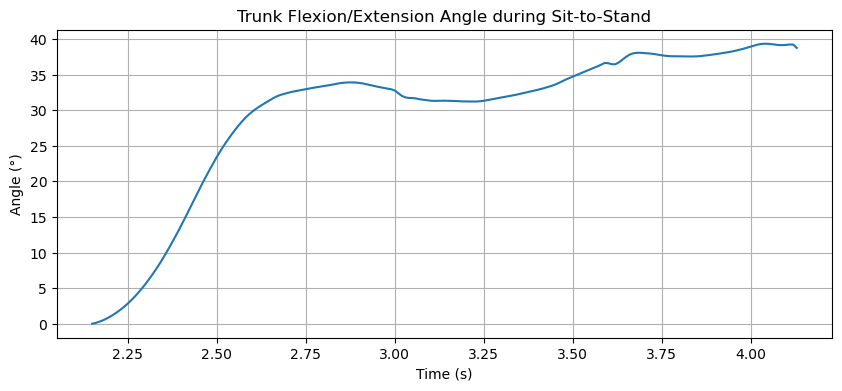

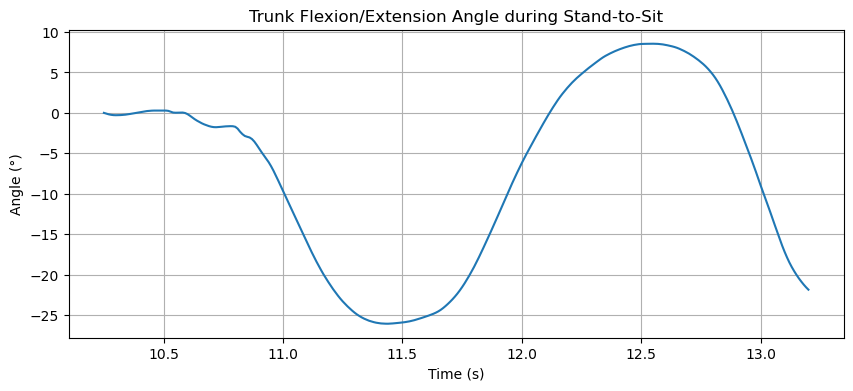


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_20_T2 ===

🔹 Processing file: 20_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_20_T2/20_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 20_2_2mW_IPhone.xls: Stride Length = 6.72 m, Gait Velocity = 6.26 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_20_T2/20_2_TUGst.xls
Skipping: 1095:1115 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1115:1136 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)


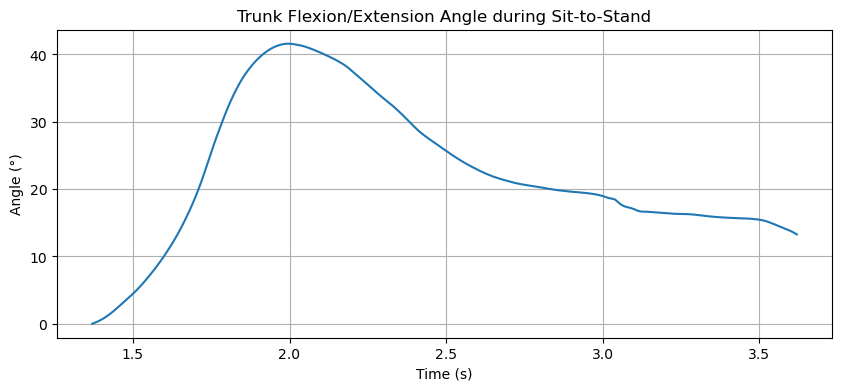

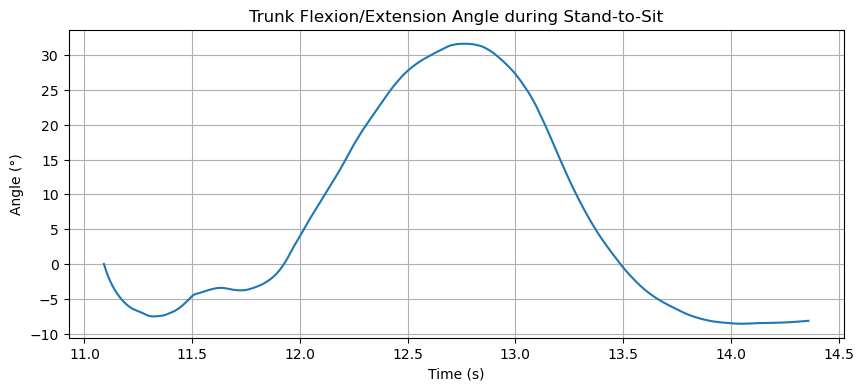


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_21_T2 ===

🔹 Processing file: 21_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_21_T2/21_2_2mW_IPhone.xls
Skipping: 12845:12941 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 21_2_2mW_IPhone.xls: Stride Length = 6.53 m, Gait Velocity = 6.65 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_21_T2/21_2_TUGst.xls
Skipping: 980:996 | index 0 is out of bounds for axis 0 with size 0
Skipping: 996:1016 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


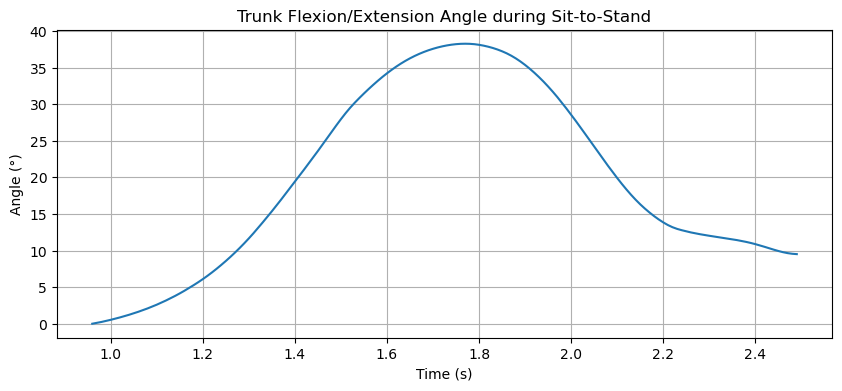

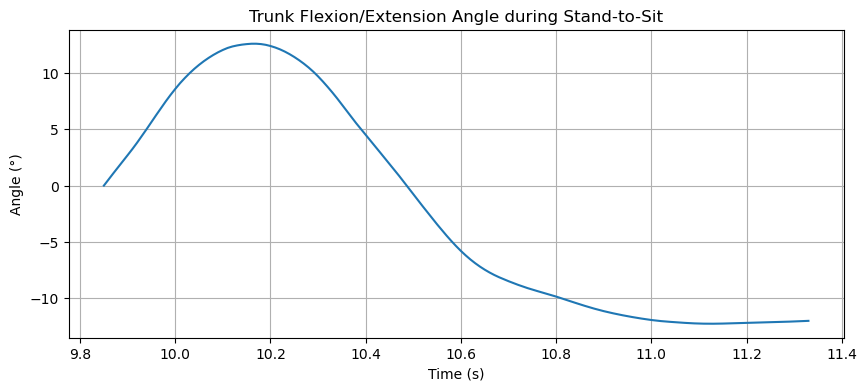


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_23_T2 ===

🔹 Processing file: 23_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_23_T2/23_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 23_2_2mW_IPhone.xls: Stride Length = 6.49 m, Gait Velocity = 6.88 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_23_T2/23_2_TUGst.xls
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)


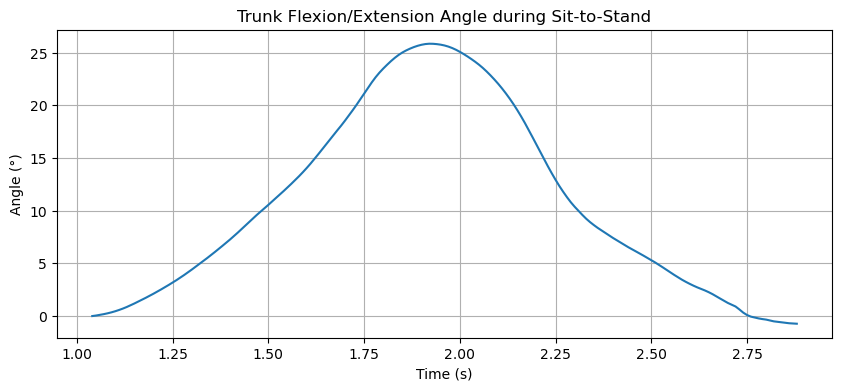

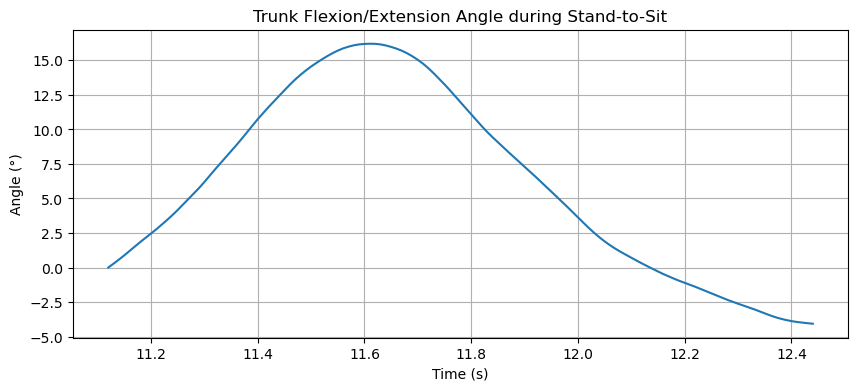


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_24_T2 ===

🔹 Processing file: 24_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_24_T2/24_2_2mW_IPhone.xls
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 24_2_2mW_IPhone.xls: Stride Length = 7.29 m, Gait Velocity = 7.37 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_24_T2/24_2_TUGst.xls
Skipping: 447:482 | index 0 is out of bounds for axis 0 with size 0
Skipping: 879:929 | index 0 is out of bounds for axis 0 with size 0
Skipping: 929:952 | index 0 is out of bounds for axis 0 with size 0
Skipping: 952:975 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)
❌ Error processing 24: Turn-1 occurs before sit-to-stand – check signal / labels.

=== Running inference for subject fold

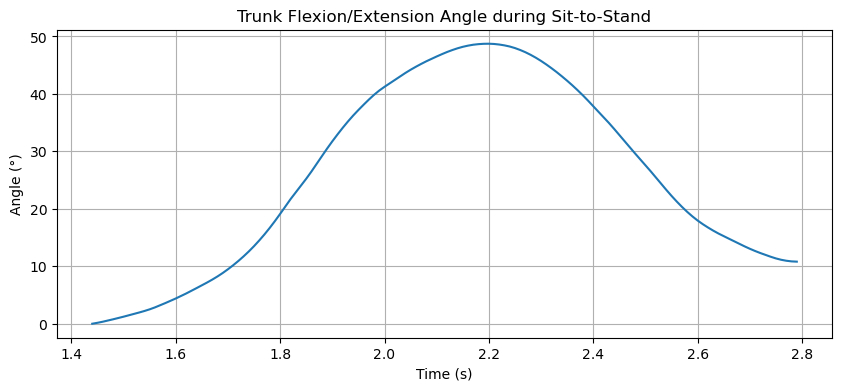

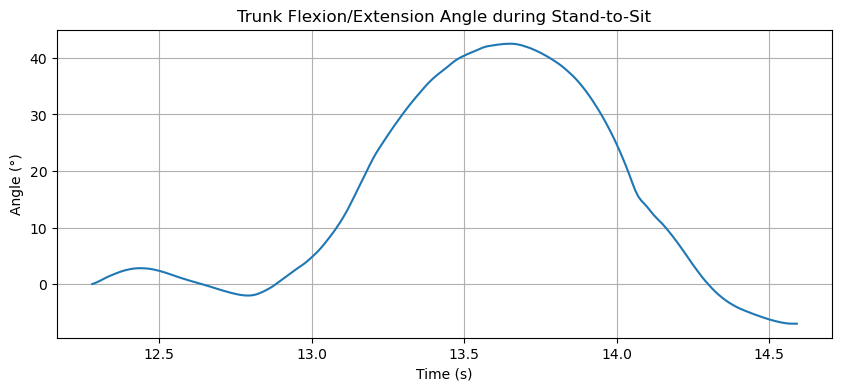


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_26_T2 ===

🔹 Processing file: 26_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_26_T2/26_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 26_2_2mW_IPhone.xls: Stride Length = 6.64 m, Gait Velocity = 7.55 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_26_T2/26_2_TUGst.xls
Skipping: 908:947 | index 0 is out of bounds for axis 0 with size 0
Skipping: 947:970 | index 0 is out of bounds for axis 0 with size 0
Skipping: 970:993 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


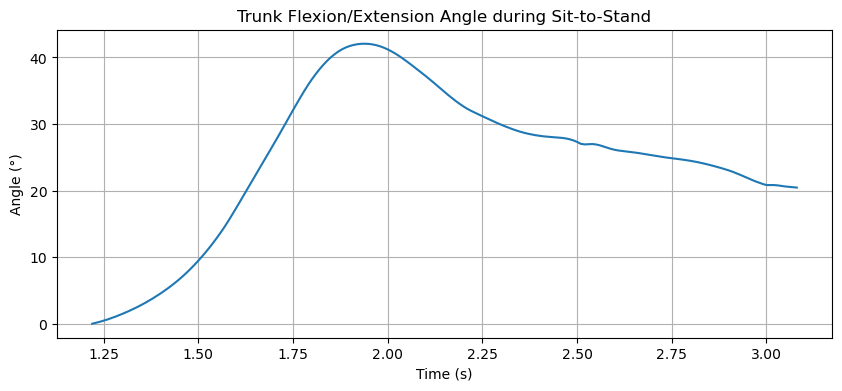

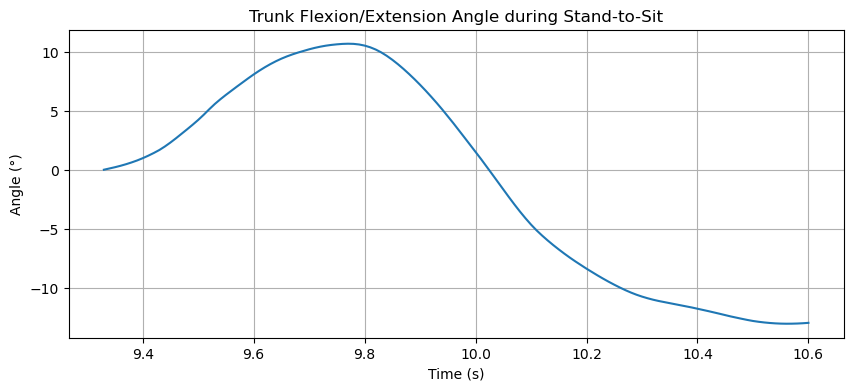


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_27_T2 ===

🔹 Processing file: 27_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_27_T2/27_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 27_2_2mW_IPhone.xls: Stride Length = 6.95 m, Gait Velocity = 6.22 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_27_T2/27_2_TUGst.xls
Skipping: 1229:1263 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1263:1281 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1281:1301 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1301:1344 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)


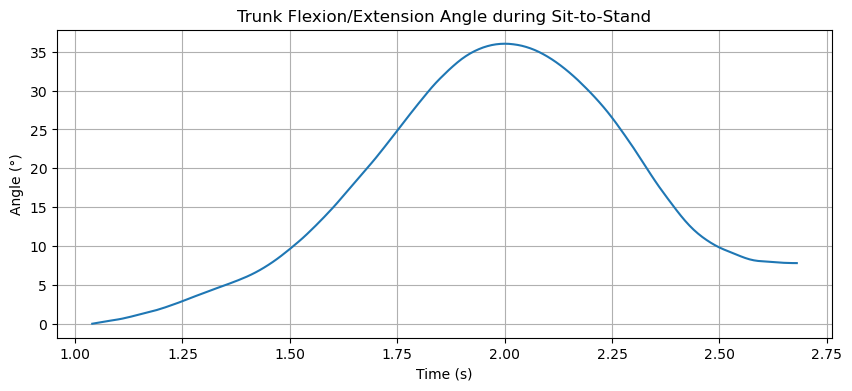

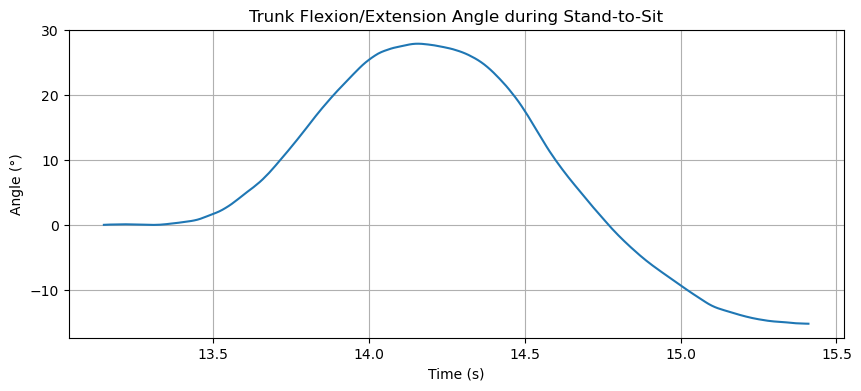


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_28_T2 ===

🔹 Processing file: 28_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_28_T2/28_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 28_2_2mW_IPhone.xls: Stride Length = 6.58 m, Gait Velocity = 6.86 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_28_T2/28_2_TUGst.xls
Skipping: 940:969 | index 0 is out of bounds for axis 0 with size 0
Skipping: 998:1069 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


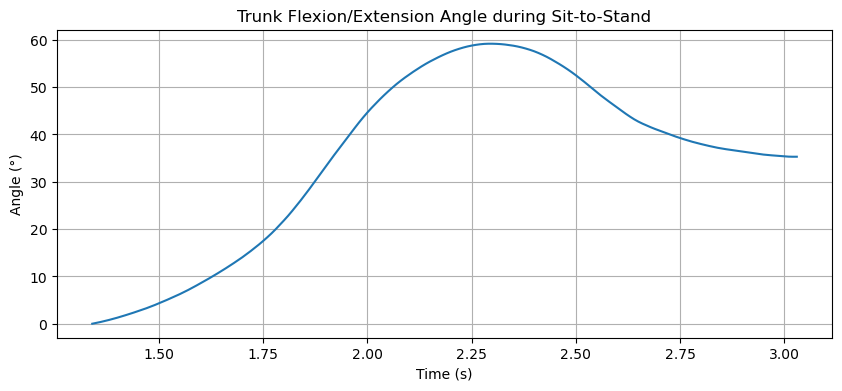

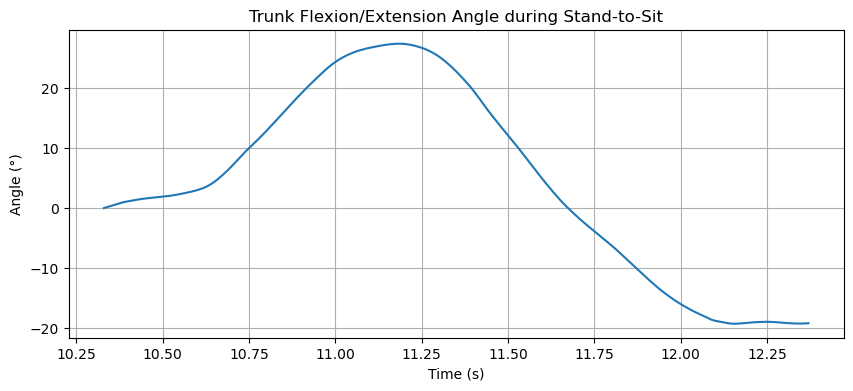


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_29_T2 ===

🔹 Processing file: 29_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_29_T2/29_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
❌ Error processing /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_29_T2/29_2_2mW_IPhone.xls: No static windows could be found to extract sensor offset orientation. Please check your input data or try to adapt parameters like window_length, static_signal_th or used metric.
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_29_T2/29_2_TUGst.xls
Skipping: 290:315 | index 0 is out of bounds for axis 0 with size 0
Skipping: 375:400 | index 0 is out of bounds for axis 0 with size 0
Skipping: 461:485 | index 0 is out of bounds for axis 0 with size 0
Skipping: 485:508 | index 0 is out of bounds for axis 0 with 

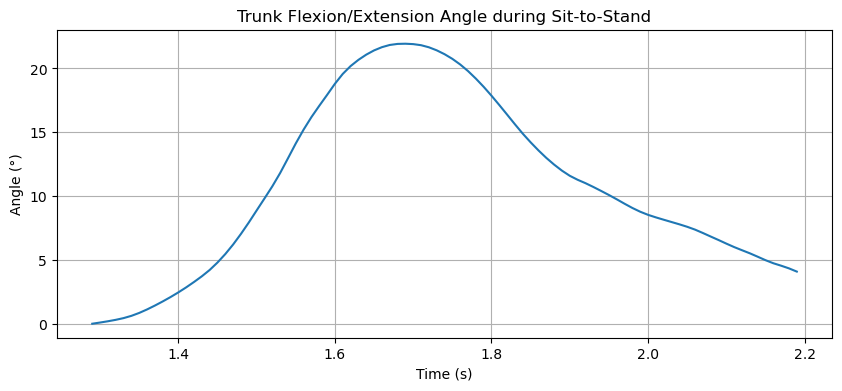

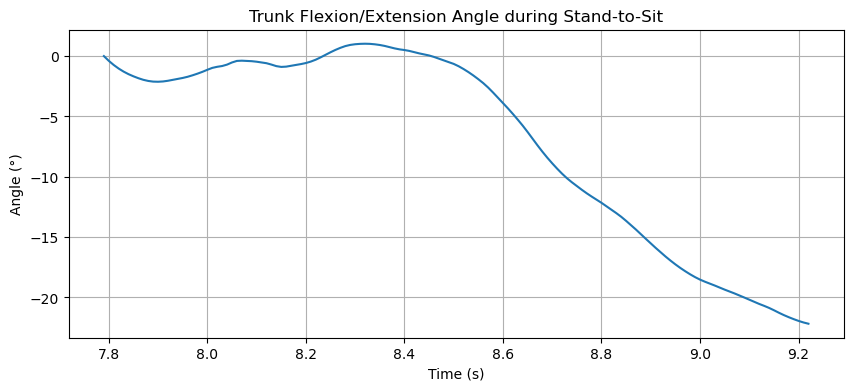


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_30_T2 ===

🔹 Processing file: 30_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_30_T2/30_2_2mW_IPhone.xls
Skipping: 12806:12897 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 30_2_2mW_IPhone.xls: Stride Length = 6.75 m, Gait Velocity = 7.27 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_30_T2/30_2_TUGst.xls
Skipping: 336:366 | index 0 is out of bounds for axis 0 with size 0
Skipping: 434:466 | index 0 is out of bounds for axis 0 with size 0
Skipping: 754:784 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


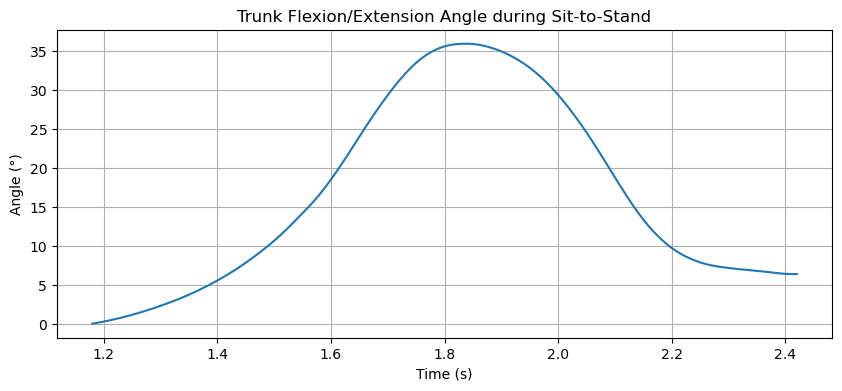

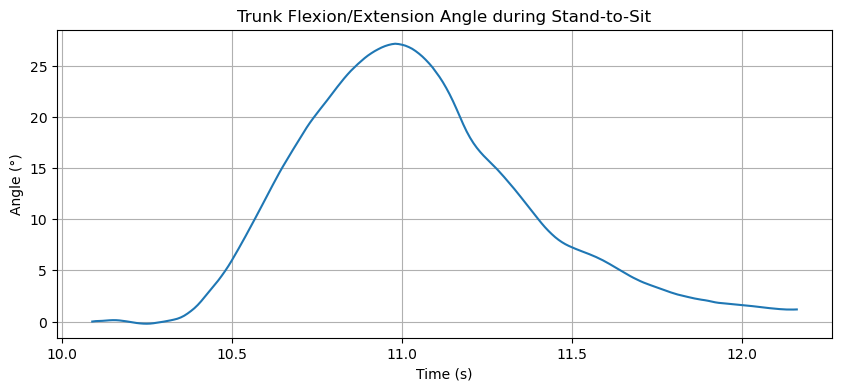


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_31_T2 ===

🔹 Processing file: 31_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_31_T2/31_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 31_2_2mW_IPhone.xls: Stride Length = 6.99 m, Gait Velocity = 8.32 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_31_T2/31_2_TUGst.xls
Skipping: 699:731 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1190:1221 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1221:1252 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (11, 256, 7)
all_arrays shape: (11, 256, 7)


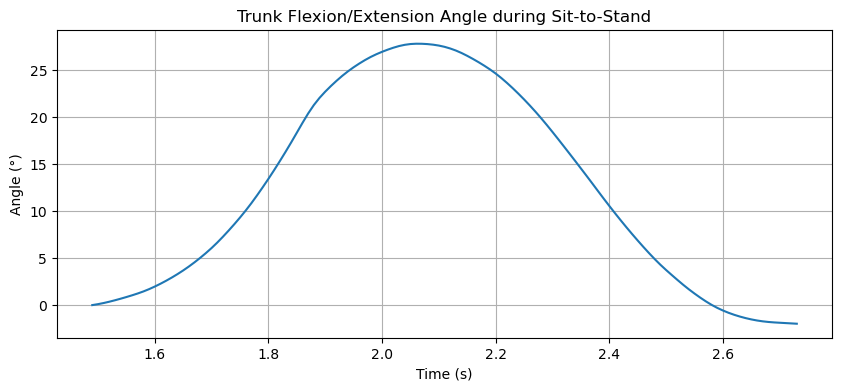

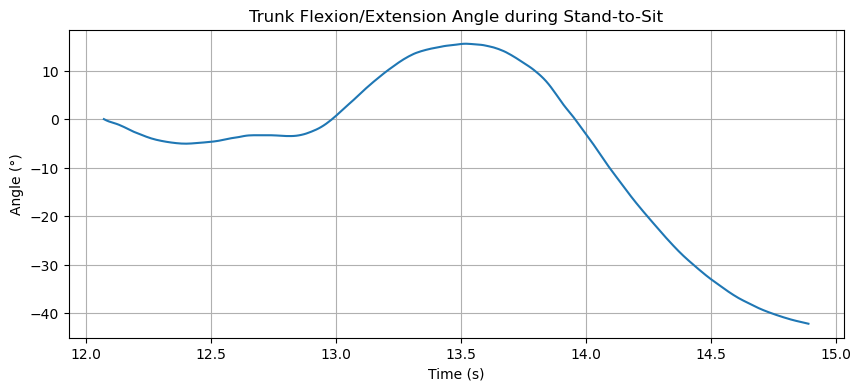


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_32_T2 ===

🔹 Processing file: 32_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_32_T2/32_2_2mW_IPhone.xls
cropped_array shape: (100, 256, 7)
all_arrays shape: (100, 256, 7)
✅ 32_2_2mW_IPhone.xls: Stride Length = 7.07 m, Gait Velocity = 7.20 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_32_T2/32_2_TUGst.xls
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


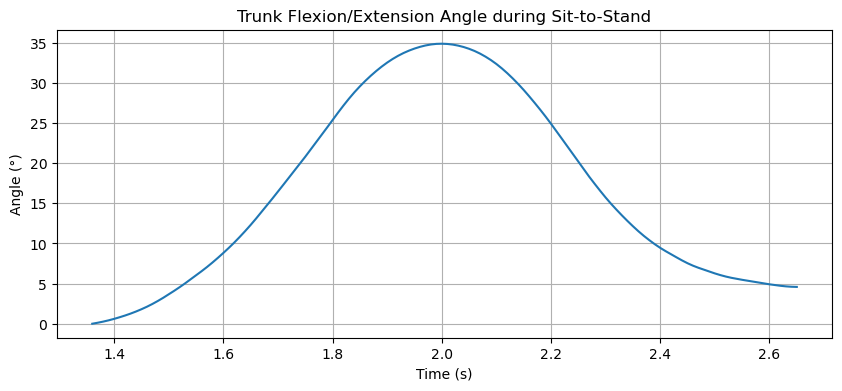

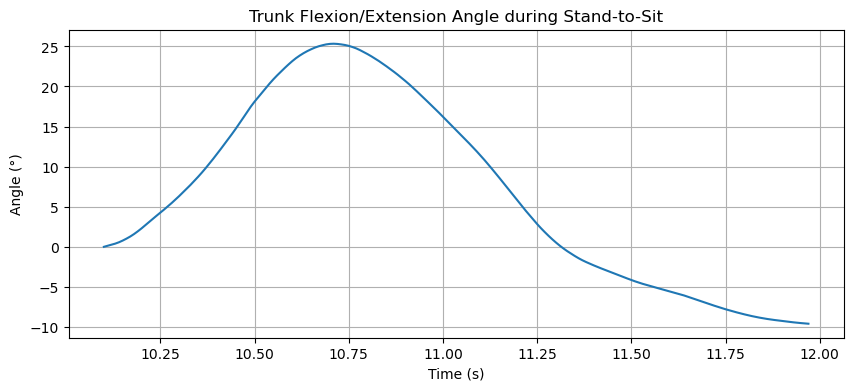


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_33_T2 ===

🔹 Processing file: 33_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_33_T2/33_2_2mW_IPhone.xls
Skipping: 12717:12807 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 33_2_2mW_IPhone.xls: Stride Length = 6.81 m, Gait Velocity = 7.86 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_33_T2/33_2_TUGst.xls
Skipping: 1204:1222 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1222:1240 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)


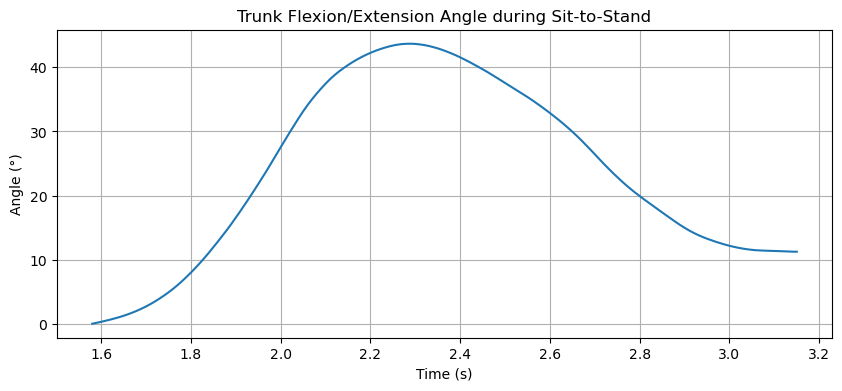

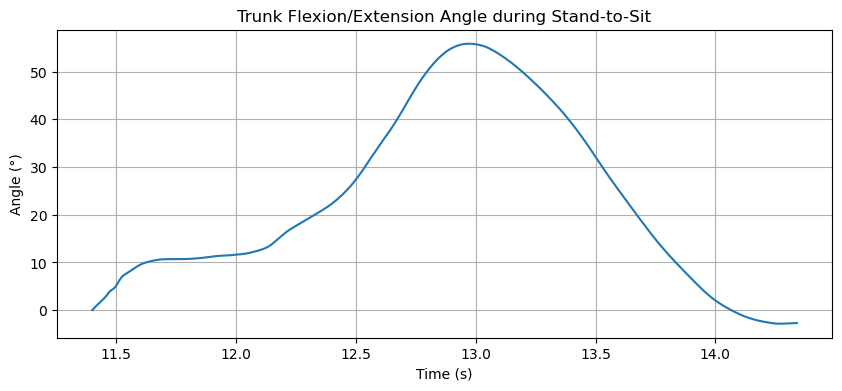


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_34_T2 ===

🔹 Processing file: 34_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_34_T2/34_2_2mW_IPhone.xls
cropped_array shape: (105, 256, 7)
all_arrays shape: (105, 256, 7)
✅ 34_2_2mW_IPhone.xls: Stride Length = 7.51 m, Gait Velocity = 7.47 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_34_T2/34_2_TUGst.xls
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)


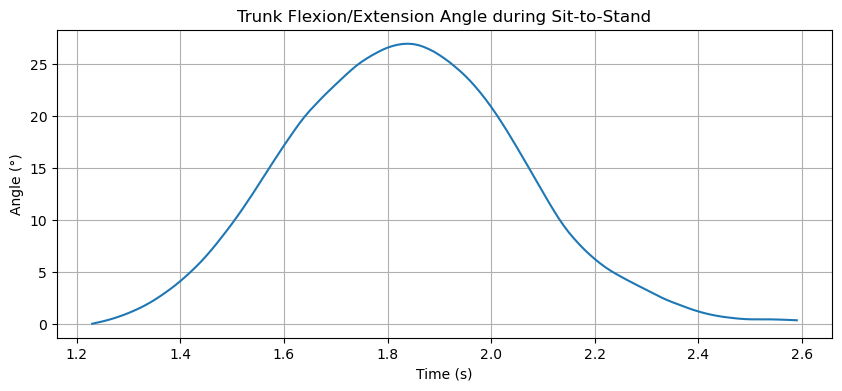

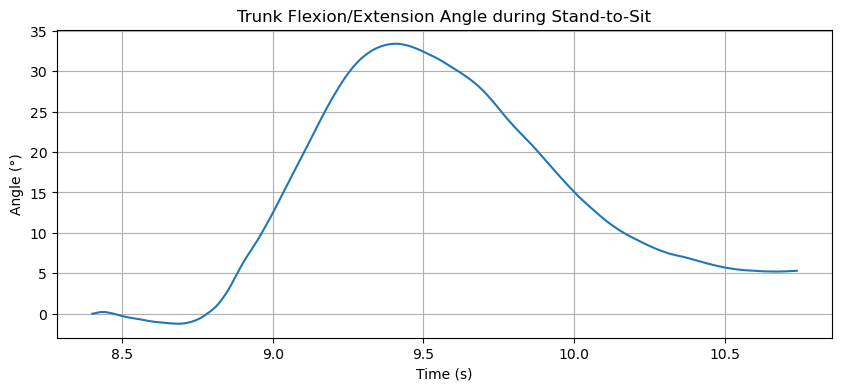


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_35_T2 ===

🔹 Processing file: 35_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_35_T2/35_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 35_2_2mW_IPhone.xls: Stride Length = 6.81 m, Gait Velocity = 7.74 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_35_T2/35_2_TUGst.xls
Skipping: 1014:1041 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1041:1058 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1058:1075 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


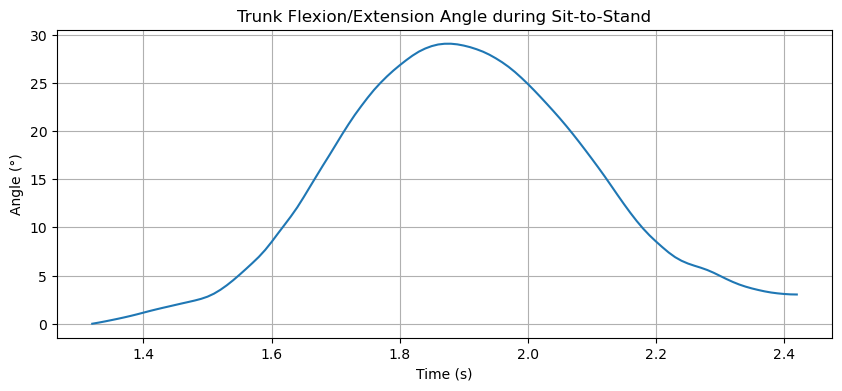

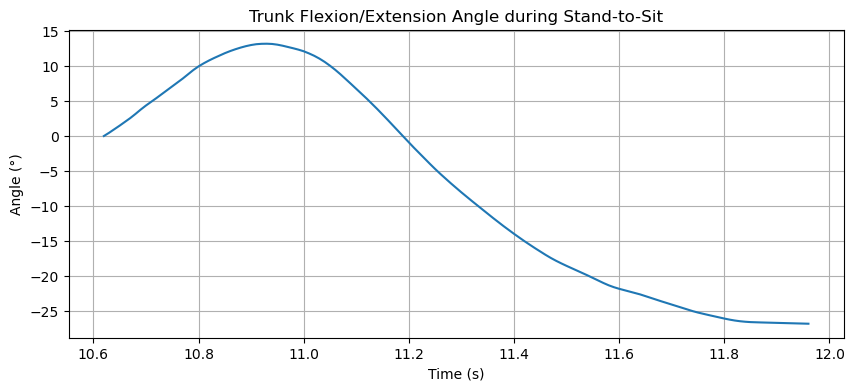


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_36_T2 ===

🔹 Processing file: 36_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_36_T2/36_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 36_2_2mW_IPhone.xls: Stride Length = 7.14 m, Gait Velocity = 8.00 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_36_T2/36_2_TUGst.xls
Skipping: 847:916 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)
❌ Error processing 36: Turn-1 occurs before sit-to-stand – check signal / labels.

=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_37_T2 ===

🔹 Processing file: 37_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_

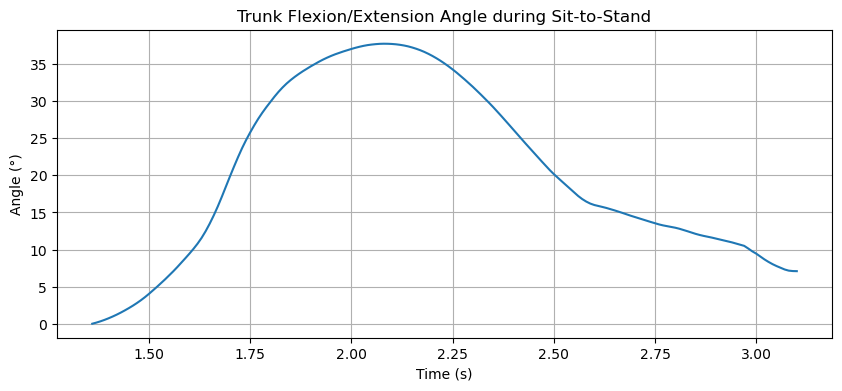

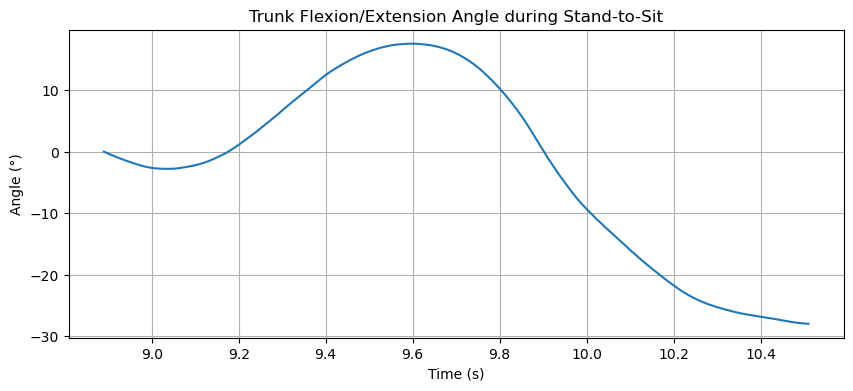


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_38_T2 ===

🔹 Processing file: 38_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_38_T2/38_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 38_2_2mW_IPhone.xls: Stride Length = 6.54 m, Gait Velocity = 7.19 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_38_T2/38_2_TUGst.xls
cropped_array shape: (10, 256, 7)
all_arrays shape: (10, 256, 7)


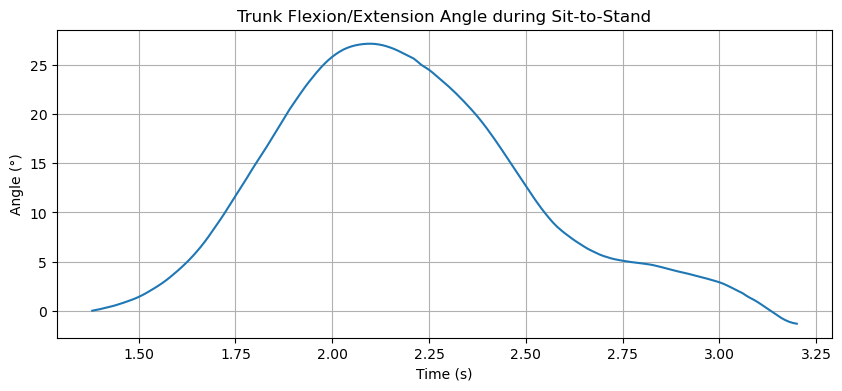

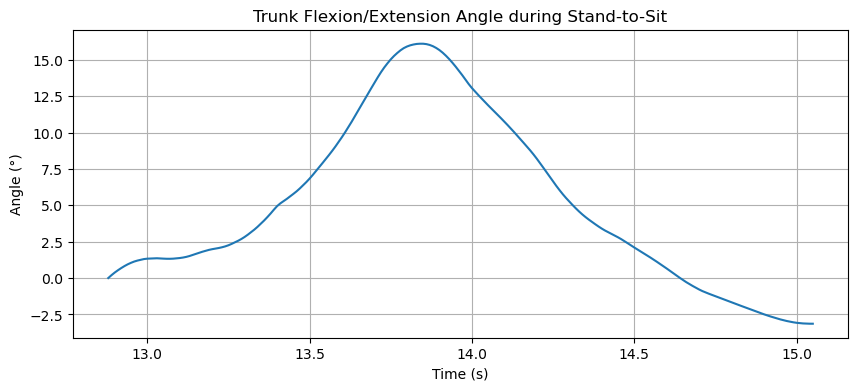


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_39_T2 ===

🔹 Processing file: 39_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_39_T2/39_2_2mW_IPhone.xls
cropped_array shape: (103, 256, 7)
all_arrays shape: (103, 256, 7)
✅ 39_2_2mW_IPhone.xls: Stride Length = 7.40 m, Gait Velocity = 8.39 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_39_T2/39_2_TUGst.xls
Skipping: 629:635 | index 0 is out of bounds for axis 0 with size 0
Skipping: 998:1035 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1035:1072 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)


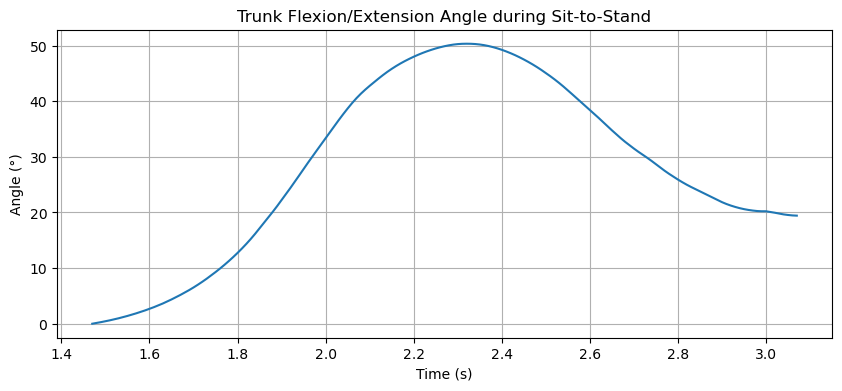

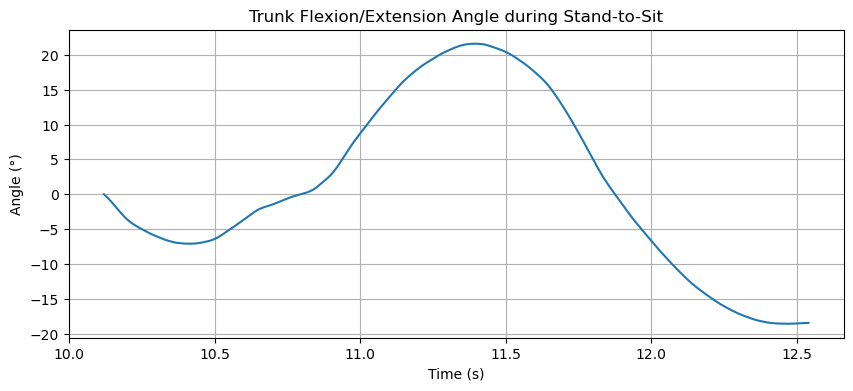


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_40_T2 ===

🔹 Processing file: 40_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_40_T2/40_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 40_2_2mW_IPhone.xls: Stride Length = 6.58 m, Gait Velocity = 7.58 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_40_T2/40_2_TUGst.xls
Skipping: 923:959 | index 0 is out of bounds for axis 0 with size 0
Skipping: 959:983 | index 0 is out of bounds for axis 0 with size 0
Skipping: 983:1014 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1014:1043 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1043:1072 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


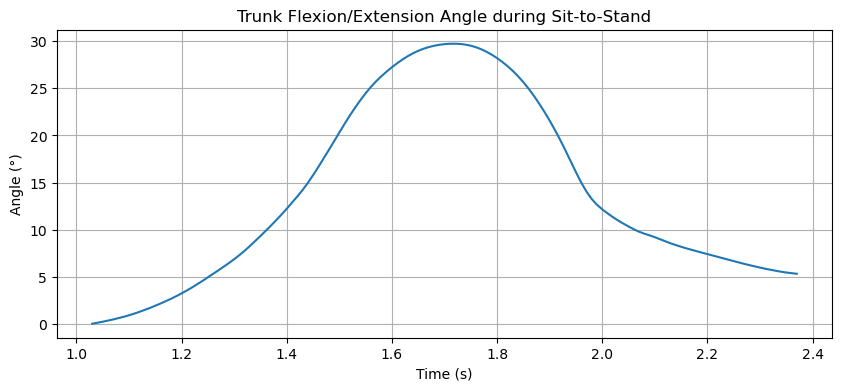

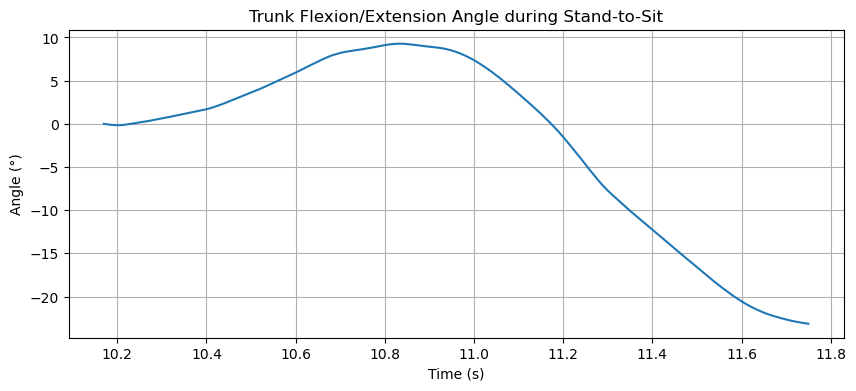


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_41_T2 ===

🔹 Processing file: 41_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_41_T2/41_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 41_2_2mW_IPhone.xls: Stride Length = 6.62 m, Gait Velocity = 7.04 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_41_T2/41_2_TUGst.xls
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


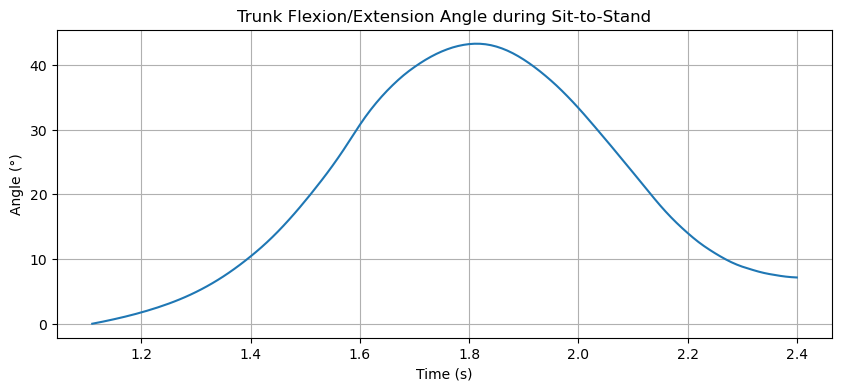

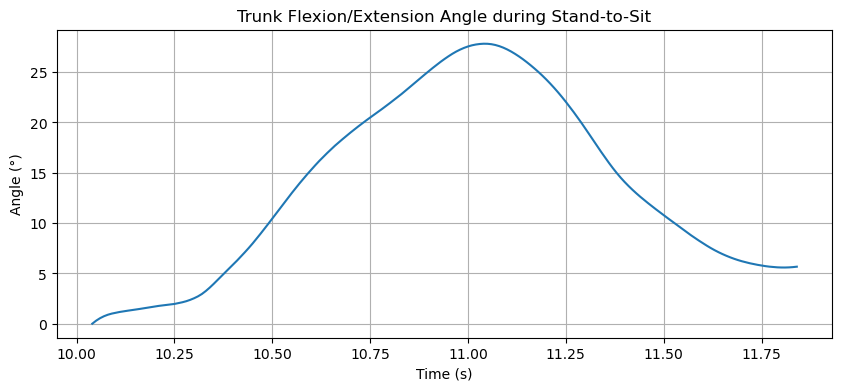


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_42_T2 ===

🔹 Processing file: 42_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_42_T2/42_2_2mW_IPhone.xls
cropped_array shape: (99, 256, 7)
all_arrays shape: (99, 256, 7)
✅ 42_2_2mW_IPhone.xls: Stride Length = 6.69 m, Gait Velocity = 6.98 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_42_T2/42_2_TUGst.xls
Skipping: 981:993 | index 0 is out of bounds for axis 0 with size 0
Skipping: 993:1005 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


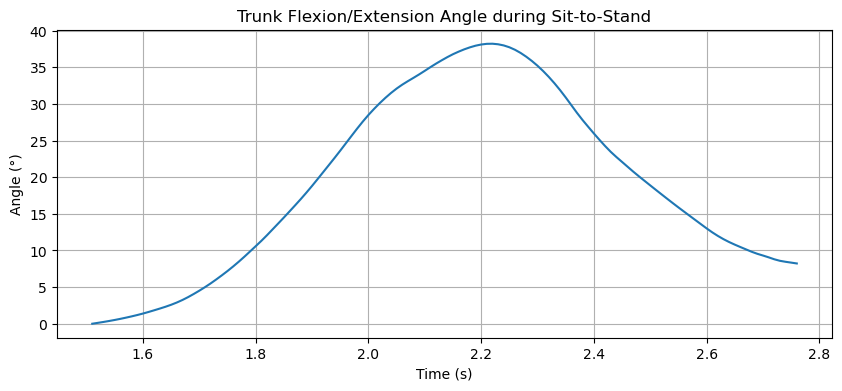

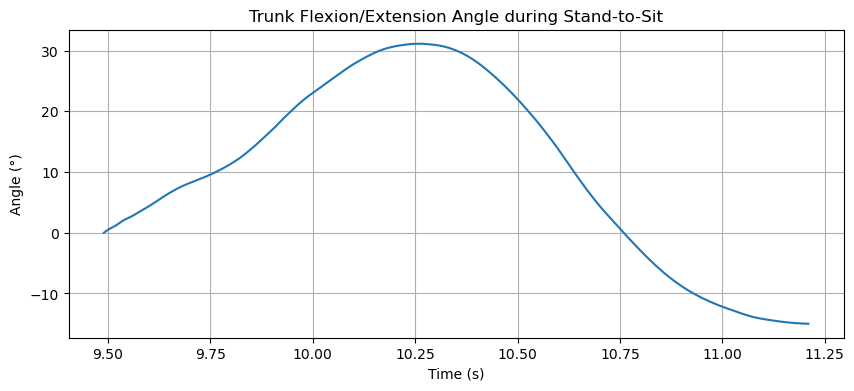


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_43_T2 ===

🔹 Processing file: 43_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_43_T2/43_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 43_2_2mW_IPhone.xls: Stride Length = 6.95 m, Gait Velocity = 7.08 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_43_T2/43_2_TUGst.xls

=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_44_T2 ===

🔹 Processing file: 44_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_44_T2/44_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 44_2_2mW_IPhone.xls: Stride Length = 6.77 m, Gait Velocity = 7.27 m/s

✅ All files processed successfully!
/home/shivams

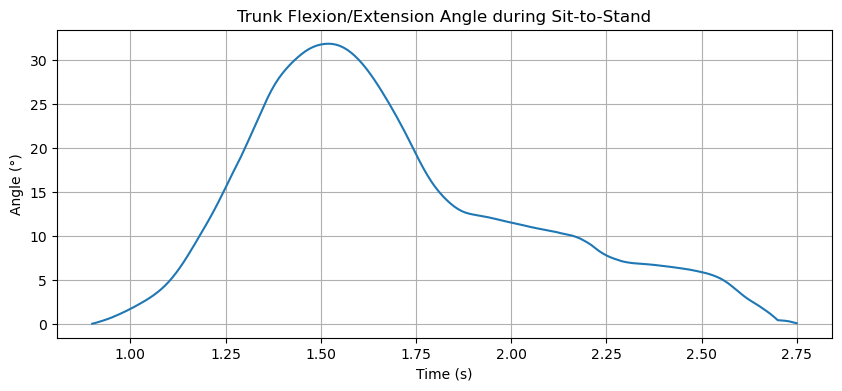

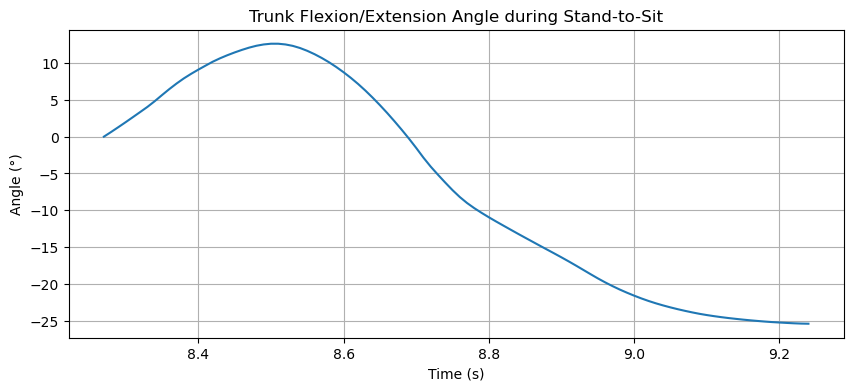


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_45_T2 ===

🔹 Processing file: 45_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_45_T2/45_2_2mW_IPhone.xls
cropped_array shape: (97, 256, 7)
all_arrays shape: (97, 256, 7)
✅ 45_2_2mW_IPhone.xls: Stride Length = 6.51 m, Gait Velocity = 6.66 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_45_T2/45_2_TUGst.xls
Skipping: 442:480 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1013:1079 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1079:1104 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1104:1129 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (9, 256, 7)
all_arrays shape: (9, 256, 7)


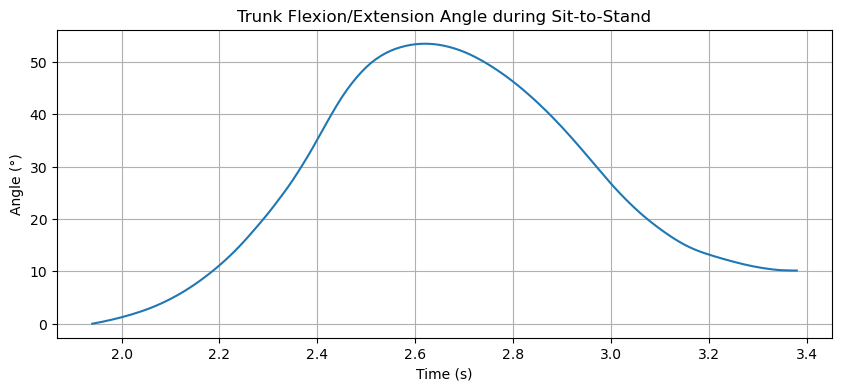

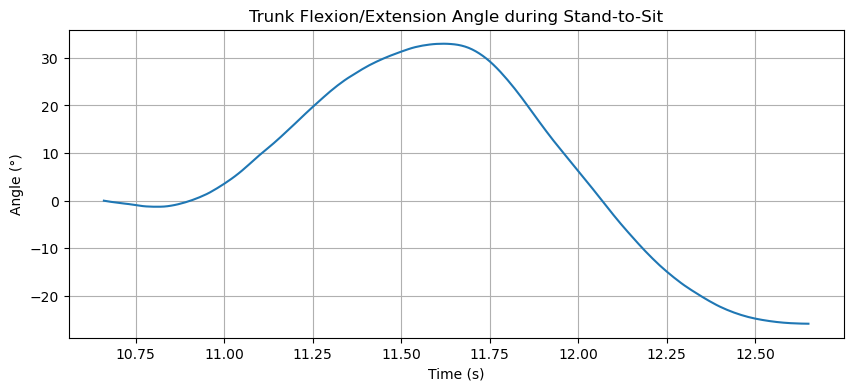


=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_47_T2 ===

🔹 Processing file: 47_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_47_T2/47_2_2mW_IPhone.xls
cropped_array shape: (98, 256, 7)
all_arrays shape: (98, 256, 7)
✅ 47_2_2mW_IPhone.xls: Stride Length = 6.65 m, Gait Velocity = 6.71 m/s

✅ All files processed successfully!
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_47_T2/47_2_TUGst.xls
Skipping: 1097:1119 | index 0 is out of bounds for axis 0 with size 0
Skipping: 1119:1141 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)


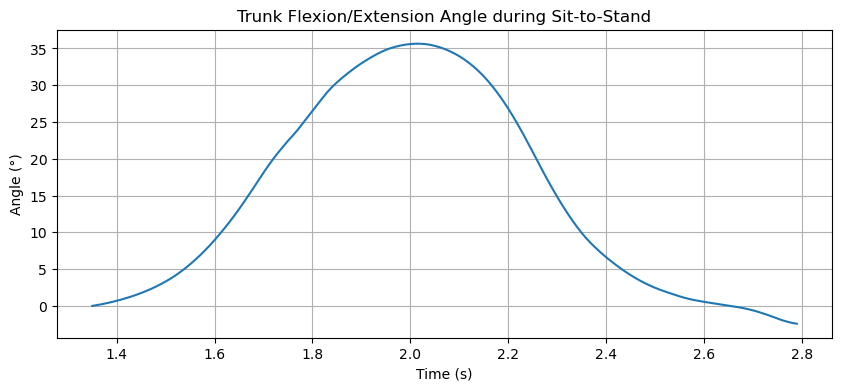

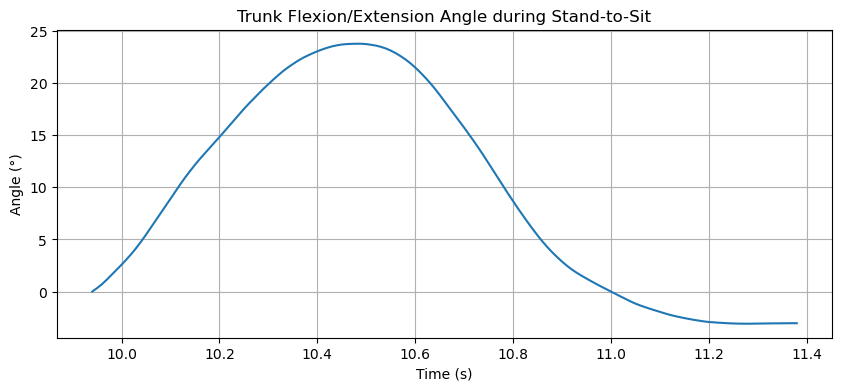


=== ALL SUBJECTS — FULL FEATURE TABLE ===


,id,mean_stride_length [m],mean_gait_velocity [m/s],max_sensor_lift [m],stride_length_spatial [m],gait_velocity_spatial [m/s],sit_to_stand [s],walk_forward [s],turn_1 [s],walk_back [s],...,Peak_angular_velocity,Mean_jerk_rms,Peak_jerk_rms,Rep_variability_jerk,file_path,label,rom_ant_deg,rom_left_deg,rom_post_deg,rom_right_deg
0,01,6.711209,6.408826,0.020348,0.943391,0.903809,1.40,2.01,2.08,1.33,...,100.79,15.19,26.28,39.18,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,10.054648,38.699282,25.239901,33.062100
1,02,6.737954,6.737807,0.115558,0.653417,0.657442,2.03,0.84,1.97,1.68,...,97.56,10.54,16.67,45.18,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,23.386383,23.010203,21.676717,21.622110
2,03,7.303543,8.544025,0.097319,0.330804,0.385920,NaN,NaN,NaN,NaN,...,96.26,23.32,44.45,66.50,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,10.129150,37.075590,15.537829,29.690210
3,04,6.822754,6.768204,0.141424,0.503864,0.502873,NaN,NaN,NaN,NaN,...,145.24,29.69,54.47,51.41,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,9.103362,28.600902,13.131319,32.271563
4,05,NaN,NaN,NaN,NaN,NaN,1.51,1.73,1.62,1.41,...,134.08,40.03,76.03,49.49,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,5.812967,18.379658,5.481985,30.492556
5,07,6.630170,7.187138,0.168969,0.352155,0.379233,1.78,1.40,2.02,1.38,...,89.64,31.36,42.84,33.33,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,9.325053,22.261098,12.243165,33.977268
6,08,6.748351,7.351885,0.118984,0.518039,0.564992,1.40,1.97,2.31,1.20,...,96.34,20.71,32.27,48.76,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,18.969190,20.155514,24.346507,34.537523
7,09,6.625998,8.138564,0.059797,0.291493,0.360115,1.20,1.83,1.89,1.94,...,80.07,21.99,33.76,51.44,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,8.388582,28.494411,4.181679,26.219814
8,10,7.078406,6.294727,0.164928,0.595153,0.549856,2.00,1.30,1.36,1.37,...,145.99,33.32,64.35,60.30,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,8.604256,21.629845,9.590424,22.583802
9,11,6.891157,7.744503,0.099489,0.406363,0.458600,1.42,1.57,2.00,1.73,...,102.68,21.28,32.66,41.65,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,19.440139,15.616018,16.249986,13.382338



=== ALL ERRORS ACROSS SUBJECTS ===


,id,subject_folder,test,error
0,03,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
1,04,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
2,05,/home/shivamsingh/Projects/SPINE/data/dataset_...,gait,empty_output
3,16,/home/shivamsingh/Projects/SPINE/data/dataset_...,trunk,Found zero norm quaternions in `quat`.
4,24,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
5,29,/home/shivamsingh/Projects/SPINE/data/dataset_...,gait,empty_output
6,36,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
7,43,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,index -1 is out of bounds for axis 0 with size 0


In [18]:
# Run full batch inference
df_all, df_errors = infer_all_subjects(
    base_folder=DATASETS_02_T2,
    subject_glob="ID_*_T2",
    verbose=True,
)

print("\n=== ALL SUBJECTS — FULL FEATURE TABLE ===")
display(df_all)

print("\n=== ALL ERRORS ACROSS SUBJECTS ===")
display(df_errors)


In [20]:
df_all

,id,mean_stride_length [m],mean_gait_velocity [m/s],max_sensor_lift [m],stride_length_spatial [m],gait_velocity_spatial [m/s],sit_to_stand [s],walk_forward [s],turn_1 [s],walk_back [s],...,Peak_angular_velocity,Mean_jerk_rms,Peak_jerk_rms,Rep_variability_jerk,file_path,label,rom_ant_deg,rom_left_deg,rom_post_deg,rom_right_deg
0,01,6.711209,6.408826,0.020348,0.943391,0.903809,1.40,2.01,2.08,1.33,...,100.79,15.19,26.28,39.18,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,10.054648,38.699282,25.239901,33.062100
1,02,6.737954,6.737807,0.115558,0.653417,0.657442,2.03,0.84,1.97,1.68,...,97.56,10.54,16.67,45.18,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,23.386383,23.010203,21.676717,21.622110
2,03,7.303543,8.544025,0.097319,0.330804,0.385920,NaN,NaN,NaN,NaN,...,96.26,23.32,44.45,66.50,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,10.129150,37.075590,15.537829,29.690210
3,04,6.822754,6.768204,0.141424,0.503864,0.502873,NaN,NaN,NaN,NaN,...,145.24,29.69,54.47,51.41,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,9.103362,28.600902,13.131319,32.271563
4,05,NaN,NaN,NaN,NaN,NaN,1.51,1.73,1.62,1.41,...,134.08,40.03,76.03,49.49,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,5.812967,18.379658,5.481985,30.492556
5,07,6.630170,7.187138,0.168969,0.352155,0.379233,1.78,1.40,2.02,1.38,...,89.64,31.36,42.84,33.33,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,9.325053,22.261098,12.243165,33.977268
6,08,6.748351,7.351885,0.118984,0.518039,0.564992,1.40,1.97,2.31,1.20,...,96.34,20.71,32.27,48.76,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,18.969190,20.155514,24.346507,34.537523
7,09,6.625998,8.138564,0.059797,0.291493,0.360115,1.20,1.83,1.89,1.94,...,80.07,21.99,33.76,51.44,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,8.388582,28.494411,4.181679,26.219814
8,10,7.078406,6.294727,0.164928,0.595153,0.549856,2.00,1.30,1.36,1.37,...,145.99,33.32,64.35,60.30,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,8.604256,21.629845,9.590424,22.583802
9,11,6.891157,7.744503,0.099489,0.406363,0.458600,1.42,1.57,2.00,1.73,...,102.68,21.28,32.66,41.65,/home/shivamsingh/Projects/SPINE/data/dataset_...,h,19.440139,15.616018,16.249986,13.382338


In [82]:
df_all.to_csv("/home/shivamsingh/Projects/SPINE/code/spine_interaction/output/inference/df_motoric_features_all_subjects.csv", index=False)
df_errors.to_csv("/home/shivamsingh/Projects/SPINE/code/spine_interaction/output/inference/df_error_motoric_features_all_subjects.csv", index=False)

# 6. Check for failed subject_files

In [21]:
df_errors

,id,subject_folder,test,error
0,03,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
1,04,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
2,05,/home/shivamsingh/Projects/SPINE/data/dataset_...,gait,empty_output
3,16,/home/shivamsingh/Projects/SPINE/data/dataset_...,trunk,Found zero norm quaternions in `quat`.
4,24,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
5,29,/home/shivamsingh/Projects/SPINE/data/dataset_...,gait,empty_output
6,36,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,'id'
7,43,/home/shivamsingh/Projects/SPINE/data/dataset_...,tug,index -1 is out of bounds for axis 0 with size 0



=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2 ===

🔹 Processing file: 01_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_2mW_IPhone.xls
filtered_arr shape: (13063, 6)
final_array shape: (13063, 7)
cropped_array shape: (101, 256, 7)
all_arrays shape: (101, 256, 7)
✅ 01_2_2mW_IPhone.xls: Stride Length = 6.66 m, Gait Velocity = 6.36 m/s

✅ All files processed successfully!
  ✓ Gait (2mW) features computed
Found 1 TUG files.
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_01_T2/01_2_TUGst.xls
Skipping: 295:330 | index 0 is out of bounds for axis 0 with size 0
Skipping: 962:979 | index 0 is out of bounds for axis 0 with size 0
filtered_arr shape: (1206, 6)
final_array shape: (1206, 7)
cropped_array shape: (8, 256, 7)
all_arrays shape: (8, 256, 7)

Processing subject: 01


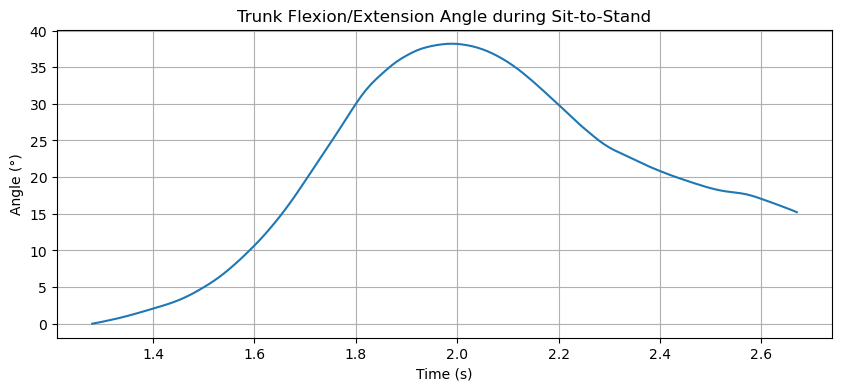

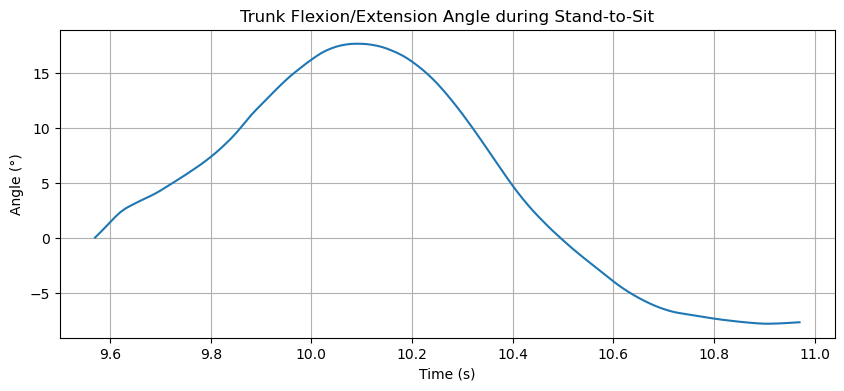


✔️ TUG feature extraction complete.
Subjects processed: 1
Subjects failed: 0
  ✓ TUG features computed
  ✓ STS-5r features computed
  ✓ Trunk ROM features computed

=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2 ===

🔹 Processing file: 02_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2/02_2_2mW_IPhone.xls
filtered_arr shape: (12597, 6)
final_array shape: (12597, 7)
cropped_array shape: (97, 256, 7)
all_arrays shape: (97, 256, 7)
✅ 02_2_2mW_IPhone.xls: Stride Length = 6.69 m, Gait Velocity = 6.69 m/s

✅ All files processed successfully!
  ✓ Gait (2mW) features computed
Found 1 TUG files.
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_02_T2/02_2_TUGst.xls
filtered_arr shape: (1123, 6)
final_array shape: (1123, 7)
cropped_array shape: (7, 256, 7)
all_arrays shape: (7, 256, 7)

Processing subject: 02


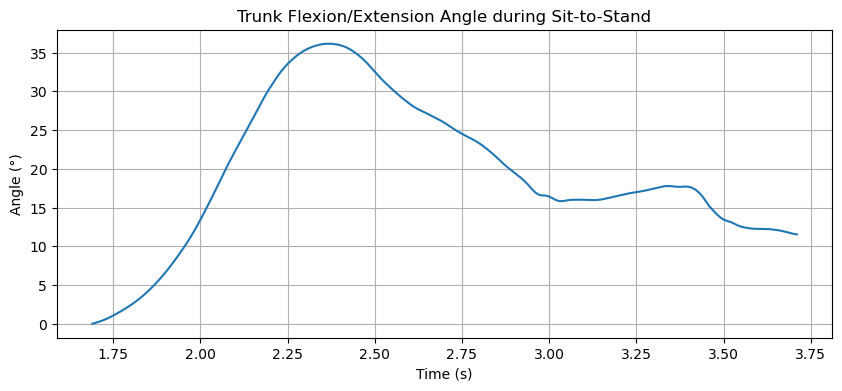

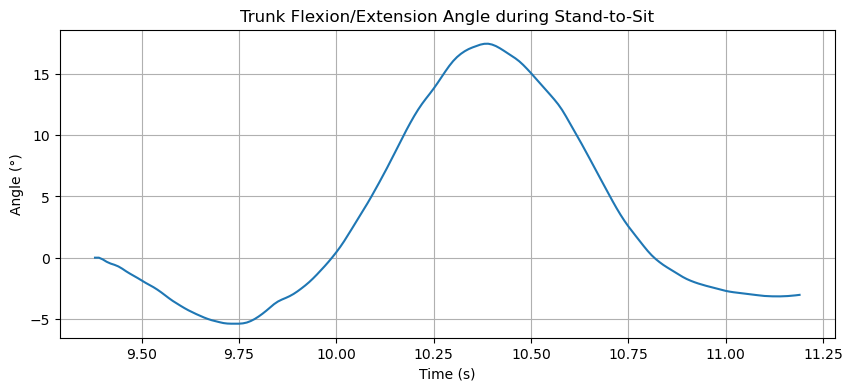


✔️ TUG feature extraction complete.
Subjects processed: 1
Subjects failed: 0
  ✓ TUG features computed
  ✓ STS-5r features computed
  ✓ Trunk ROM features computed

=== Running inference for subject folder: /home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2 ===

🔹 Processing file: 03_2_2mW_IPhone.xls
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2/03_2_2mW_IPhone.xls
Skipping: 9045:9053 | index 0 is out of bounds for axis 0 with size 0
filtered_arr shape: (13472, 6)
final_array shape: (13472, 7)
cropped_array shape: (104, 256, 7)
all_arrays shape: (104, 256, 7)
✅ 03_2_2mW_IPhone.xls: Stride Length = 7.26 m, Gait Velocity = 8.49 m/s

✅ All files processed successfully!
  ✓ Gait (2mW) features computed
Found 1 TUG files.
/home/shivamsingh/Projects/SPINE/data/dataset_02/21072025/Termin 2 Vicon/ID_03_T2/03_2_TUGst.xls
Skipping: 831:885 | index 0 is out of bounds for axis 0 with size 0
filtered_arr shape: (1028, 6)
final_arra

KeyError: 'id'

In [ ]:
# from src.inference import run_inference_for_all_subjects
# from src.spine_interaction.config import DATASETS_02_T2

# # Run on all subject folders under DATASETS_02_T2
# all_df = run_inference_for_all_subjects(
#     base_folder=DATASETS_02_T2,
#     subject_glob="ID_*_T2",
#     verbose=True,
# )

# print("=== Final ALL-Subject Feature Table ===")
# display(all_df)

# # Save results
# all_df.to_csv("/home/shivamsingh/Projects/SPINE/code/spine_interaction/output/inference/motoric_features_all_subjects.csv", index=False)